# Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import StratifiedKFold
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.naive_bayes import GaussianNB
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Đọc dữ liệu từ file CSV

In [2]:
# Đọc dữ liệu
data = r"../dataset/faults.csv"
df = pd.read_csv(data)

# Hiển thị vài dòng đầu của dữ liệu
print(df.head())

   X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
0         42         50     270900     270944           267           17   
1        645        651    2538079    2538108           108           10   
2        829        835    1553913    1553931            71            8   
3        853        860     369370     369415           176           13   
4       1289       1306     498078     498335          2409           60   

   Y_Perimeter  Sum_of_Luminosity  Minimum_of_Luminosity  \
0           44              24220                     76   
1           30              11397                     84   
2           19               7972                     99   
3           45              18996                     99   
4          260             246930                     37   

   Maximum_of_Luminosity  ...  Orientation_Index  Luminosity_Index  \
0                    108  ...             0.8182           -0.2913   
1                    123  ...             

In [3]:
# Hiển thị 5 dòng cuối của dữ liệu
df.tail()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
1936,249,277,325780,325796,273,54,22,35033,119,141,...,-0.4286,0.0026,0.7254,0,0,0,0,0,0,1
1937,144,175,340581,340598,287,44,24,34599,112,133,...,-0.4516,-0.0582,0.8173,0,0,0,0,0,0,1
1938,145,174,386779,386794,292,40,22,37572,120,140,...,-0.4828,0.0052,0.7079,0,0,0,0,0,0,1
1939,137,170,422497,422528,419,97,47,52715,117,140,...,-0.0606,-0.0171,0.9919,0,0,0,0,0,0,1
1940,1261,1281,87951,87967,103,26,22,11682,101,133,...,-0.2000,-0.1139,0.5296,0,0,0,0,0,0,1


In [4]:
#Xem kích thước của dữ liệu
df.shape

(1941, 34)

In [5]:
#Xem thông tin dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [6]:
#Thông kê mô tả dữ liệu
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
#Kiểm tra dòng bị thiếu
df.isnull()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1937,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1938,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1939,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Pastry                   0
Z_Scratch                0
K_Scatch                 0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64

# Trực quan hóa dữ liệu 

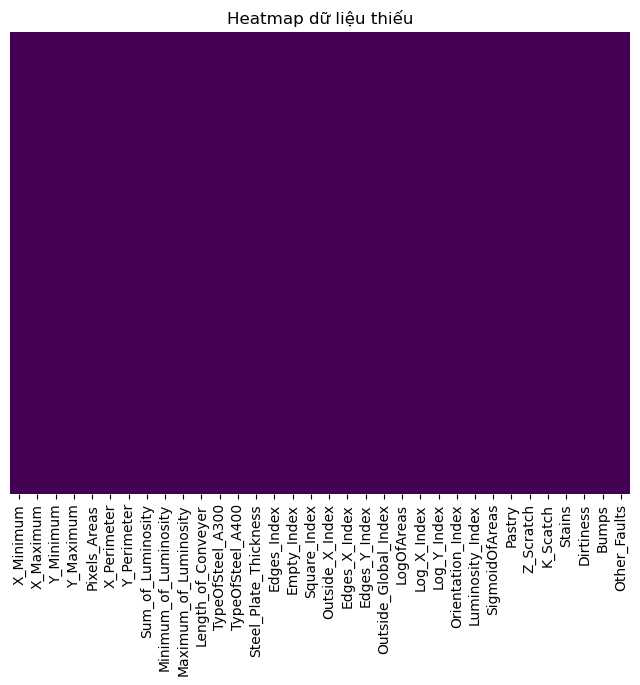

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Heatmap dữ liệu thiếu")
plt.show()

Biểu đồ phân phối

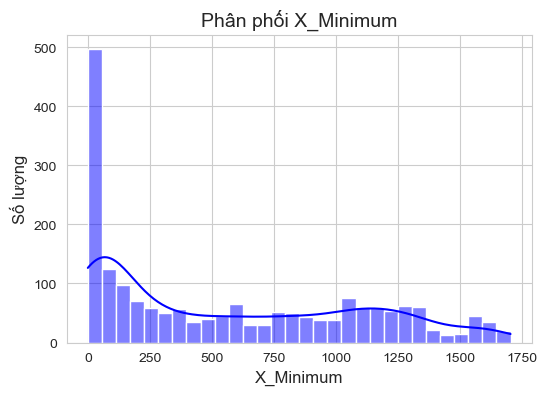

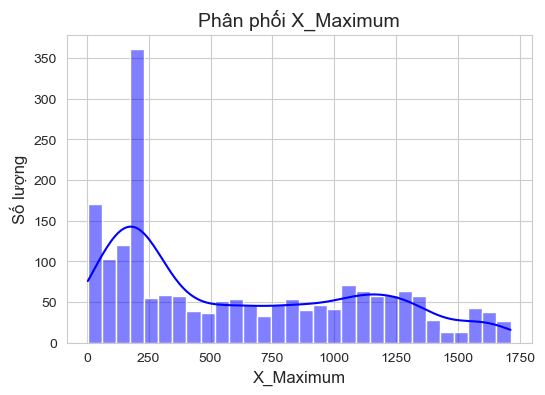

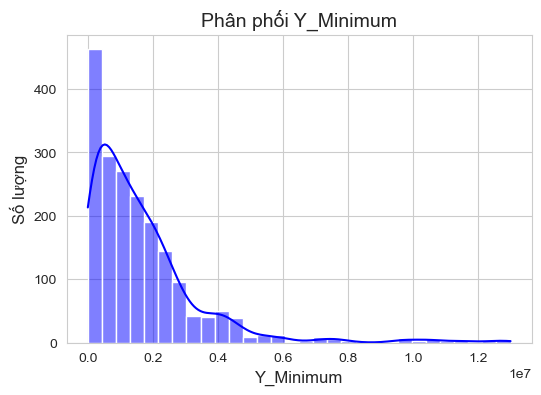

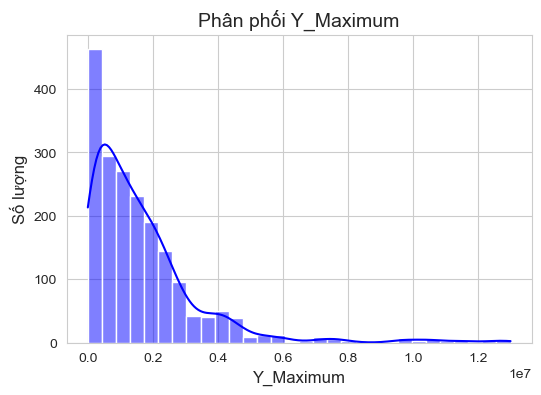

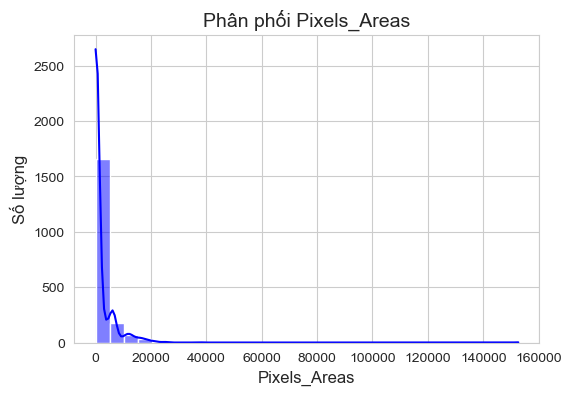

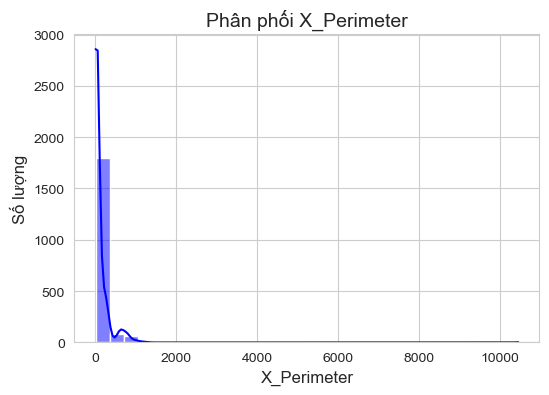

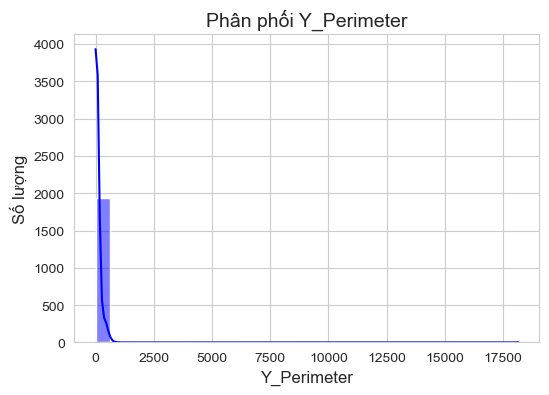

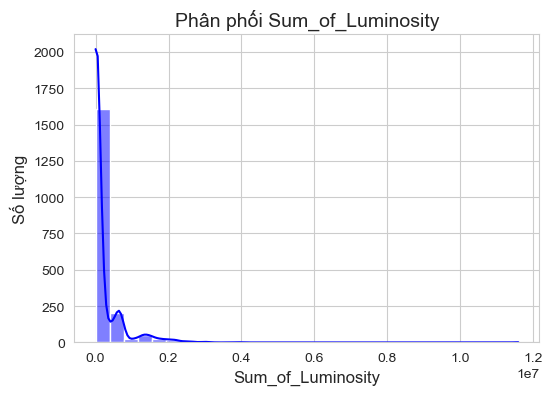

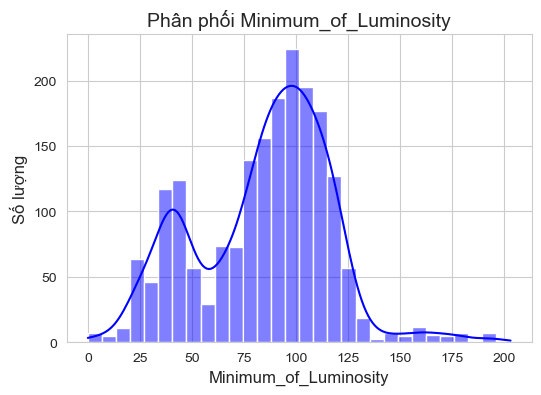

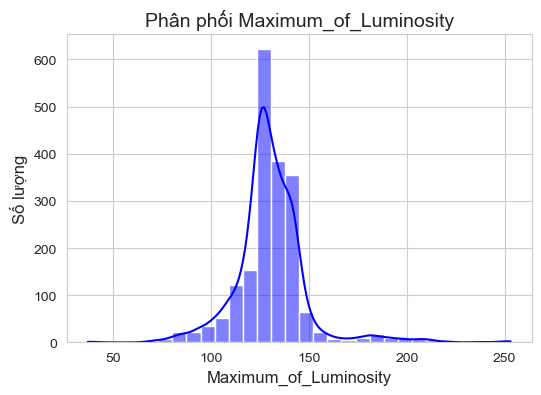

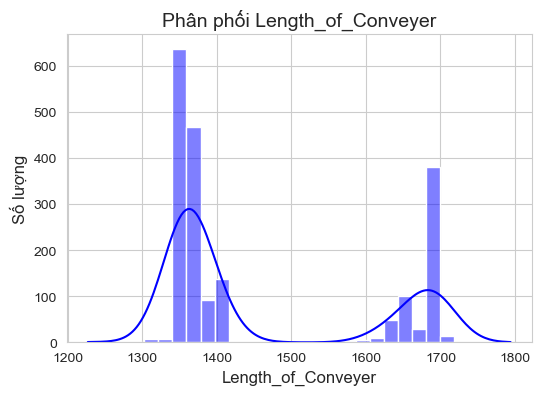

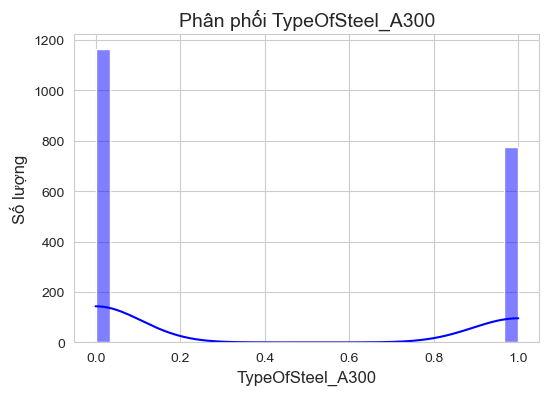

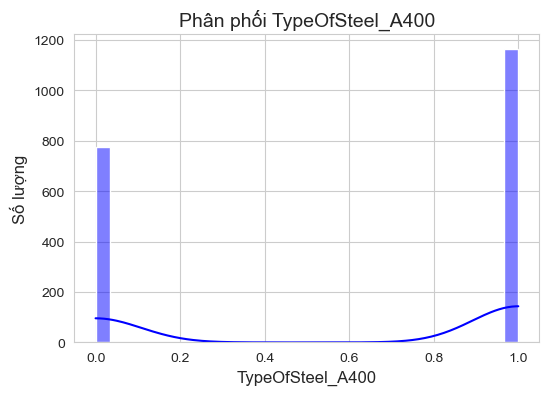

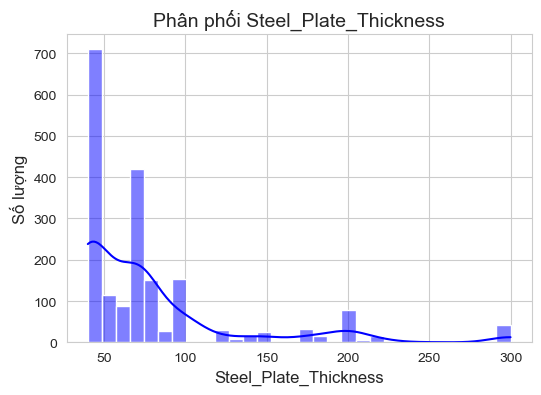

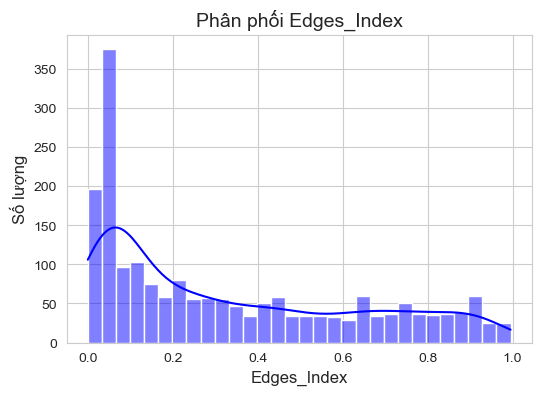

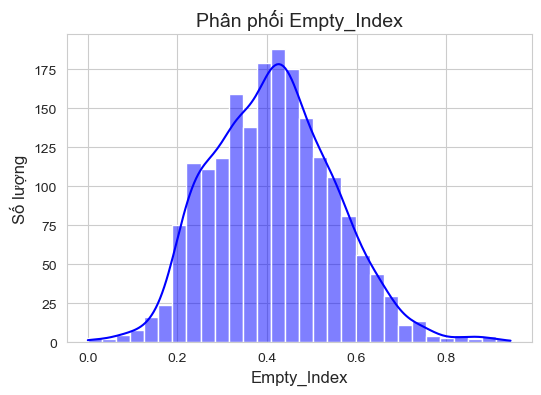

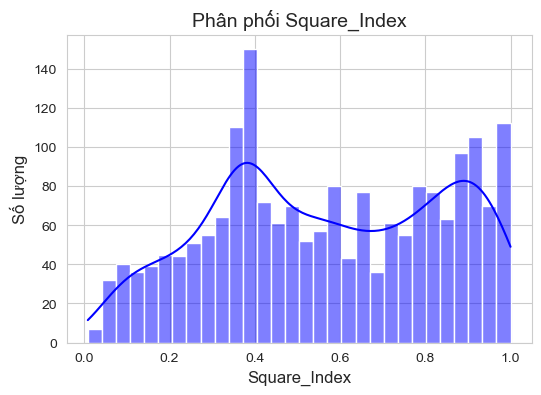

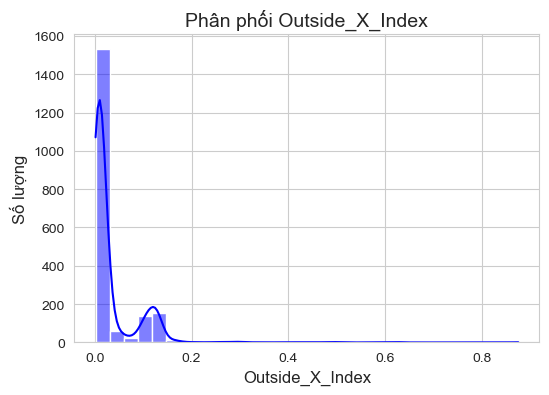

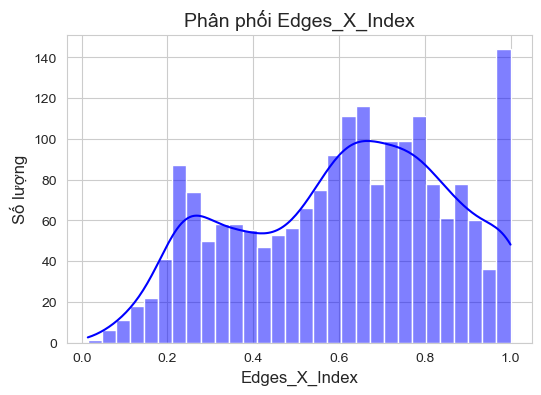

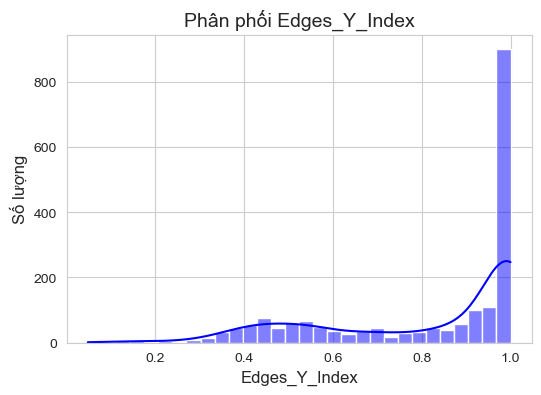

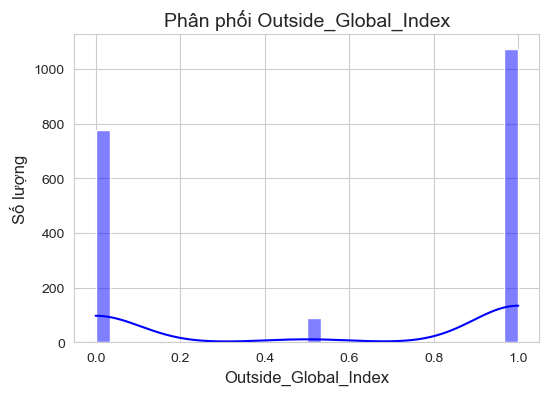

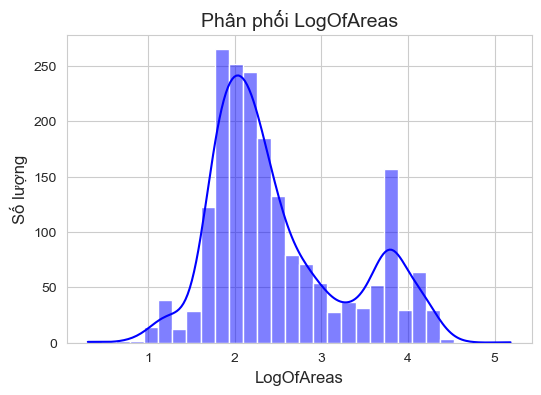

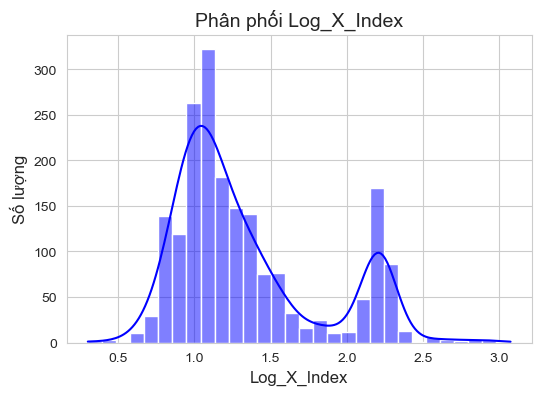

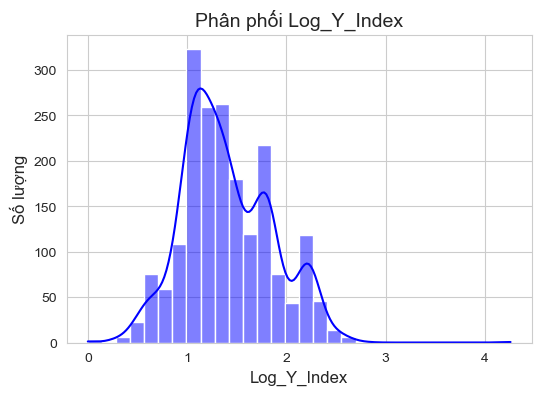

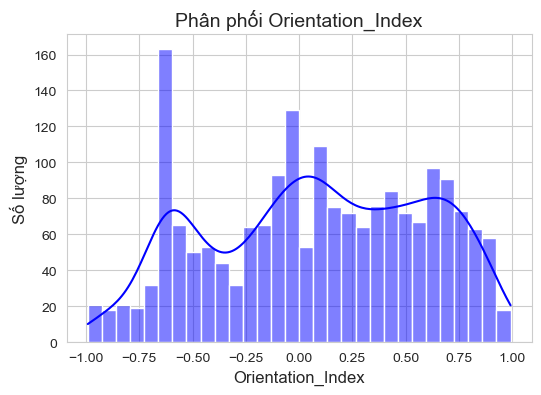

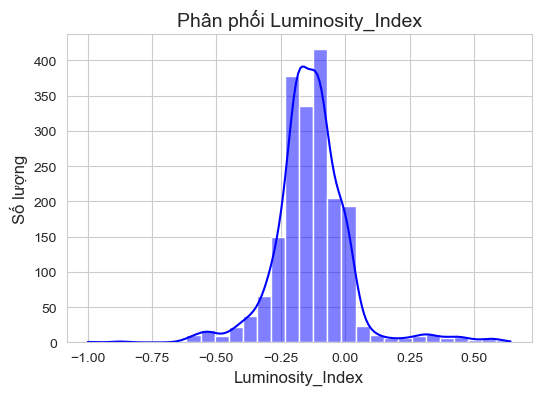

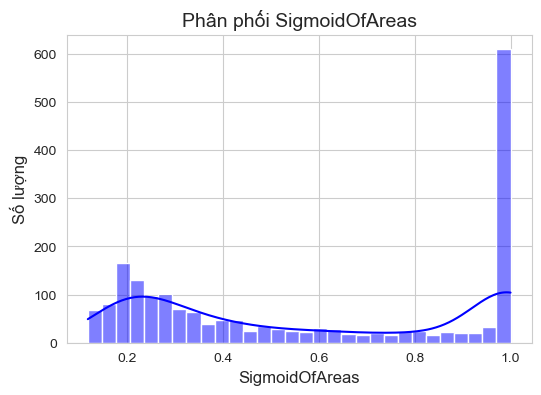

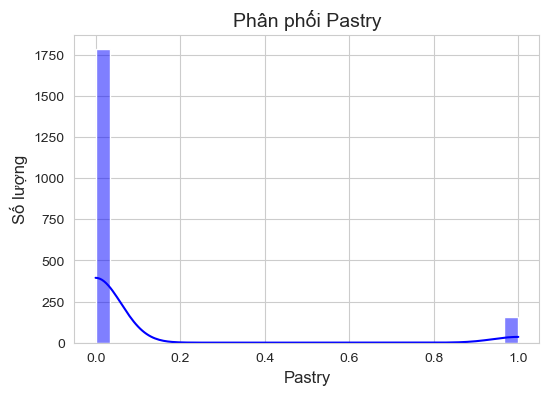

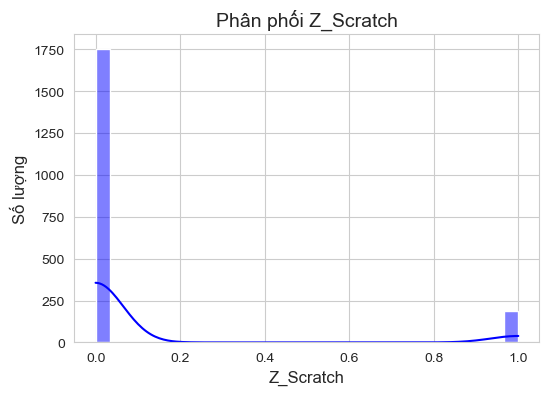

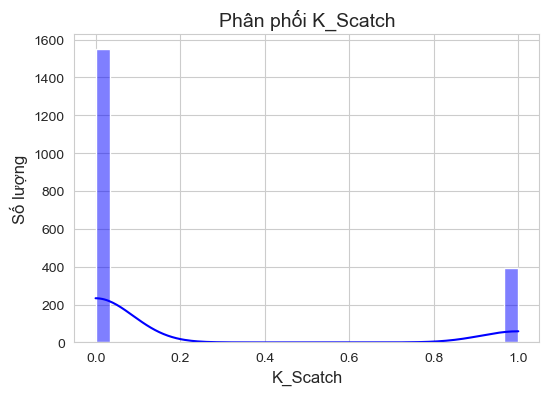

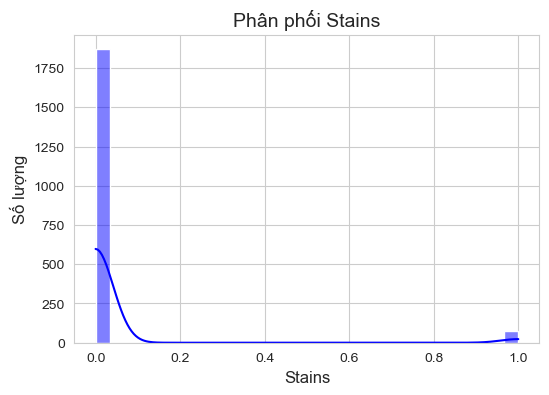

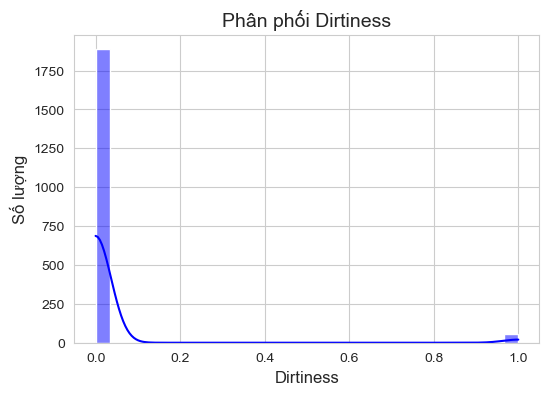

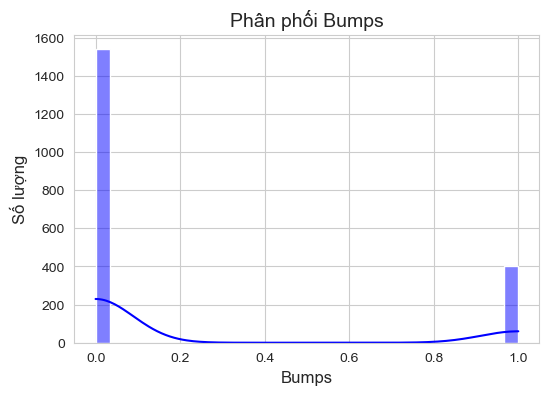

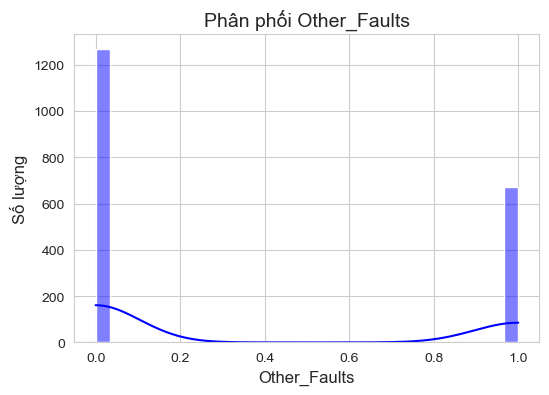

In [10]:
sns.set_style('whitegrid')
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6, 4))  
    sns.histplot(data=df, x=col, bins=30, kde=True, color='blue') 
    plt.title(f"Phân phối {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Số lượng", fontsize=12)
    plt.show()

Biểu đồ hộp

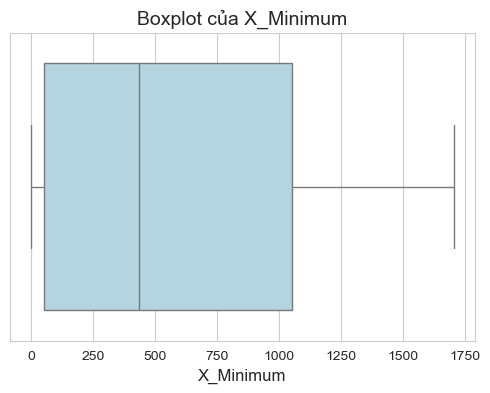

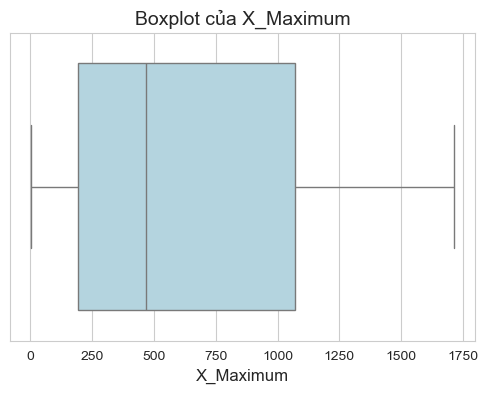

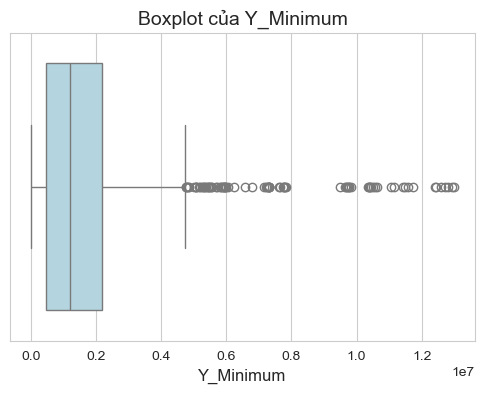

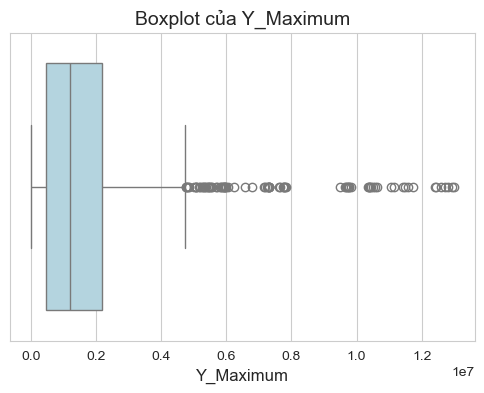

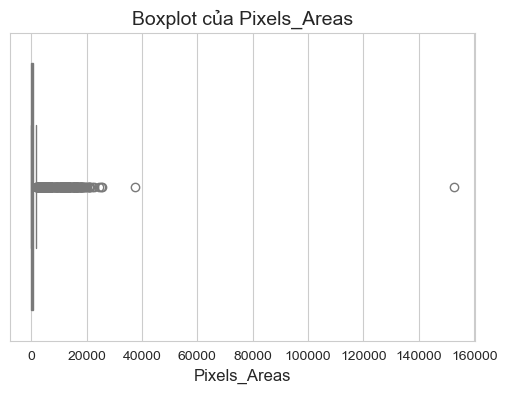

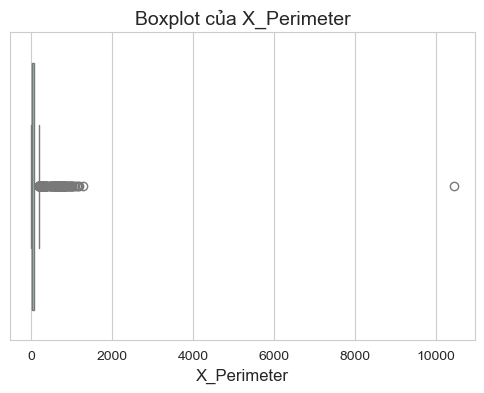

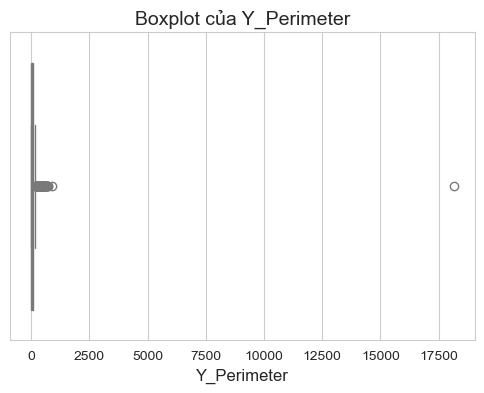

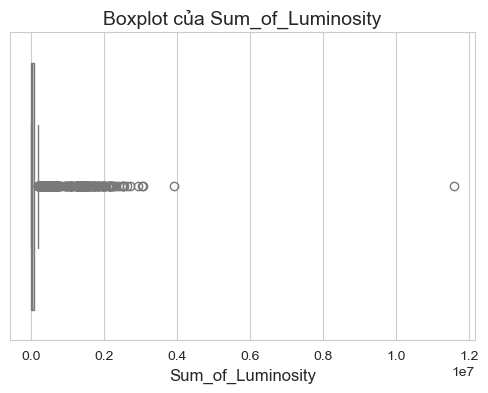

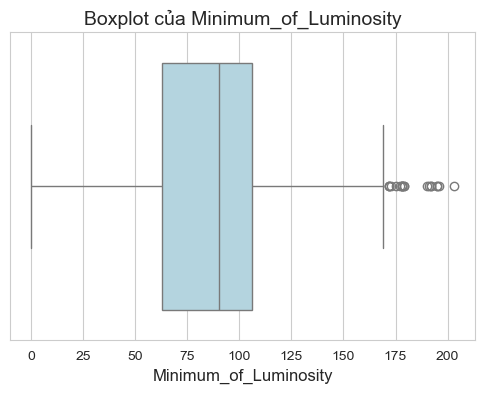

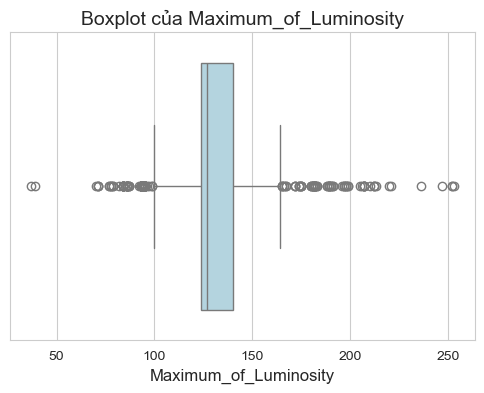

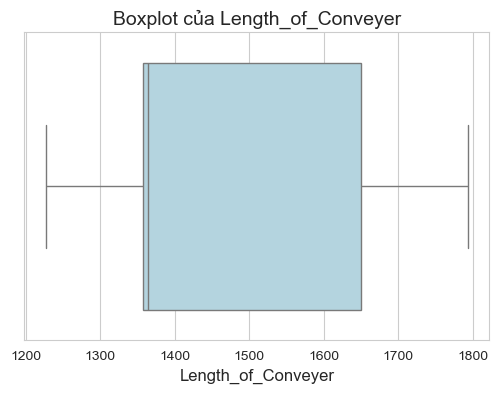

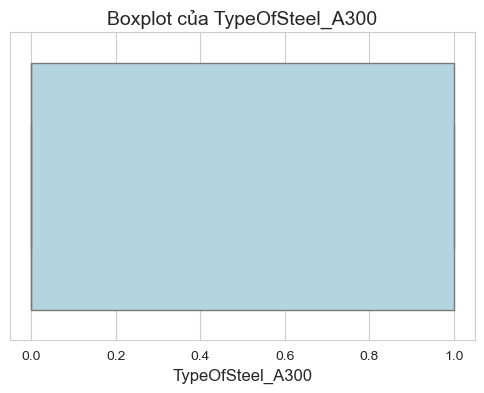

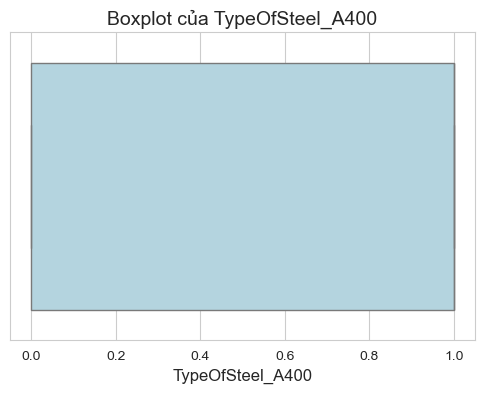

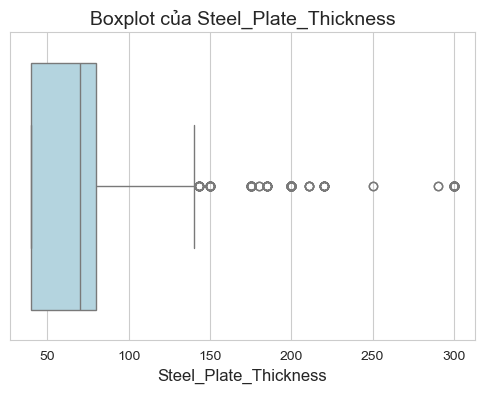

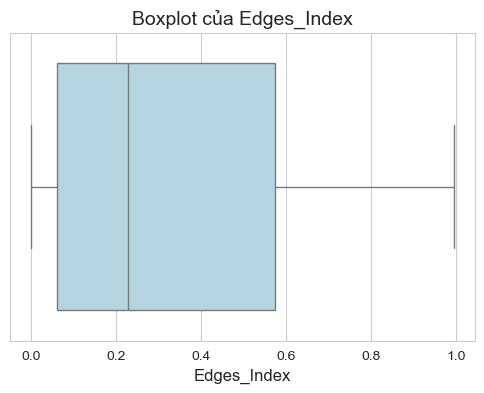

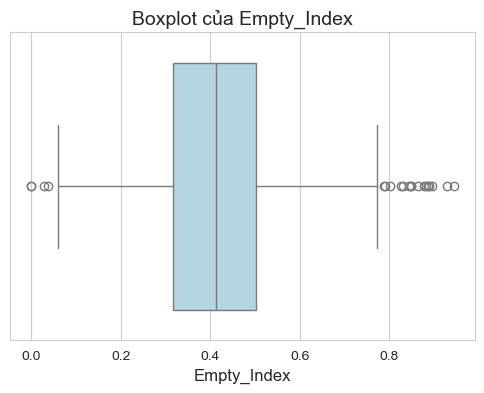

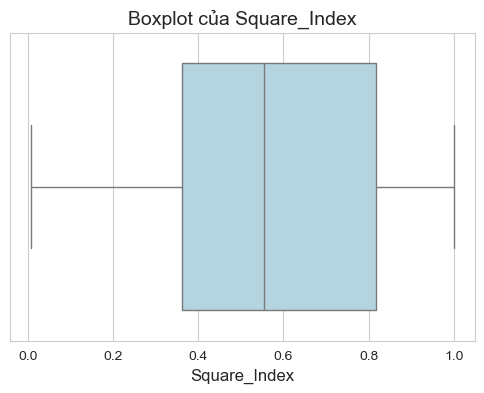

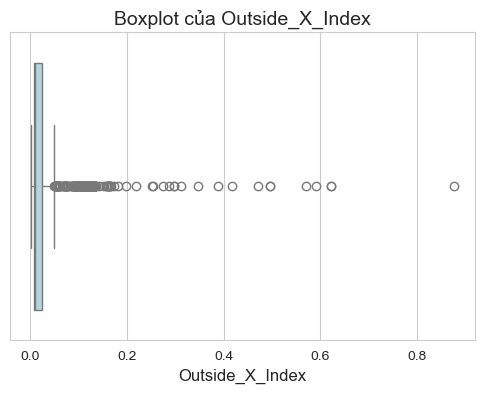

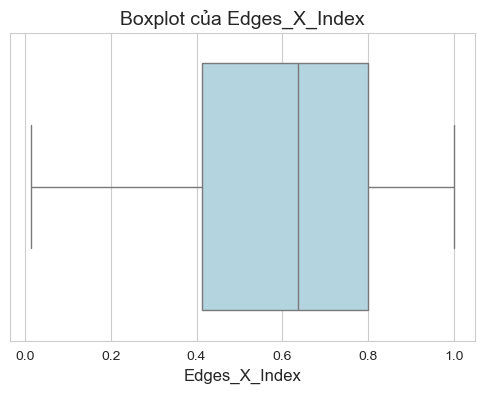

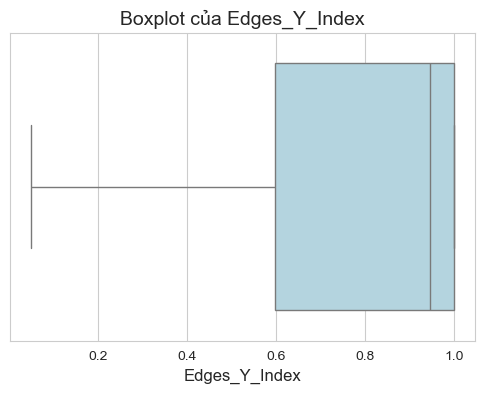

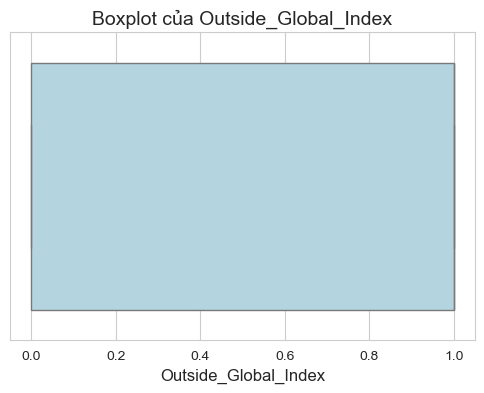

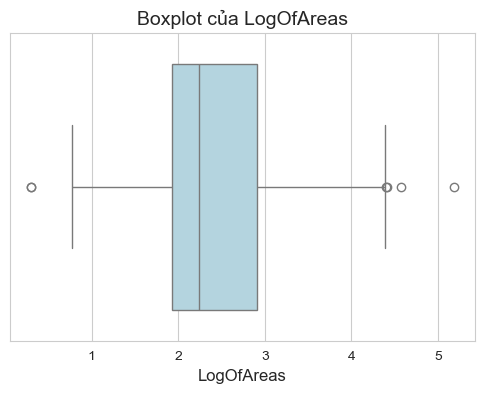

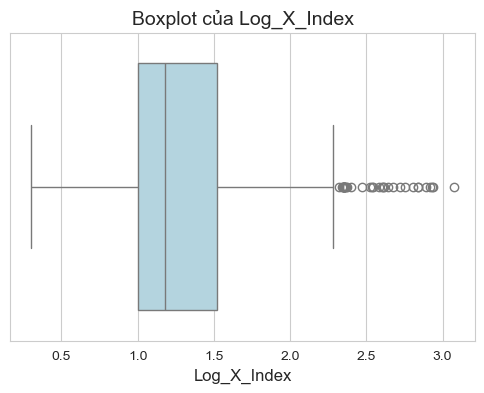

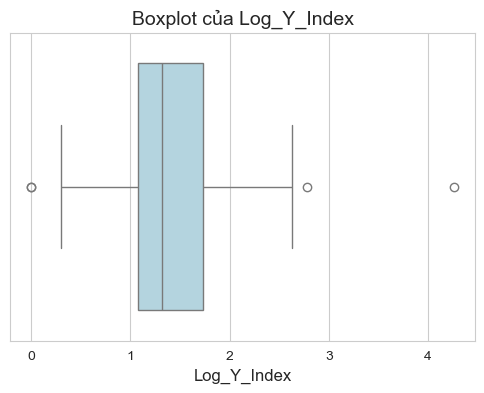

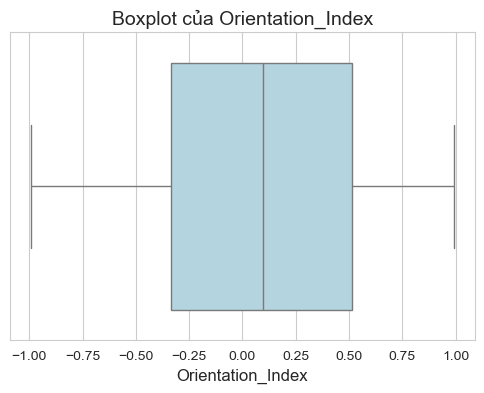

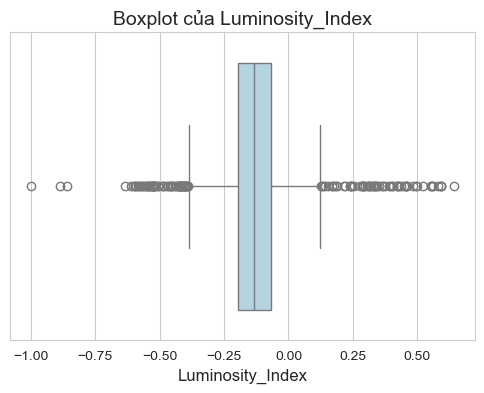

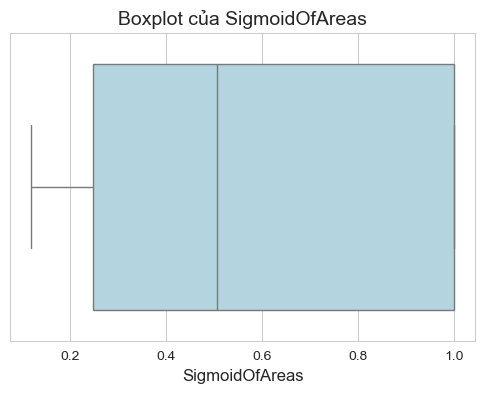

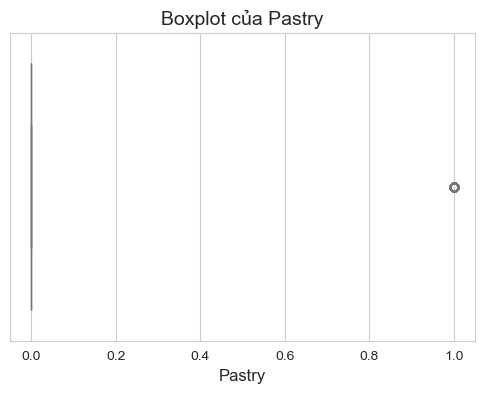

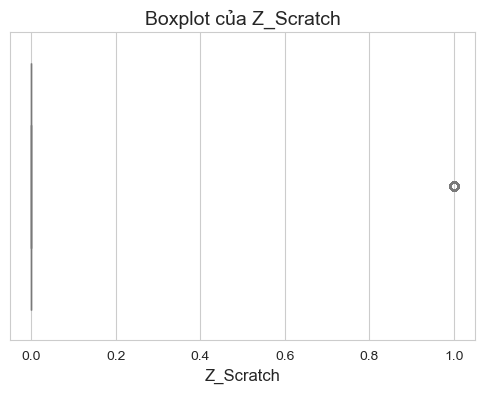

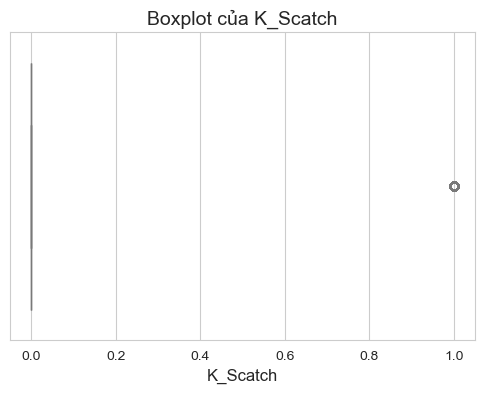

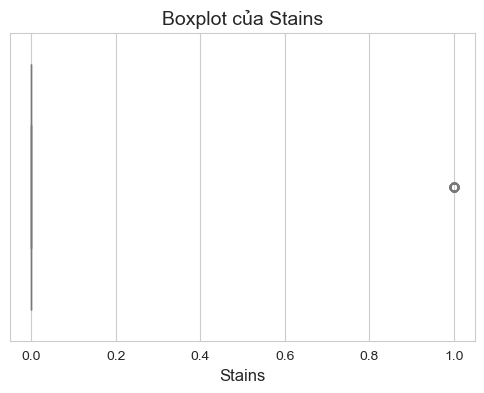

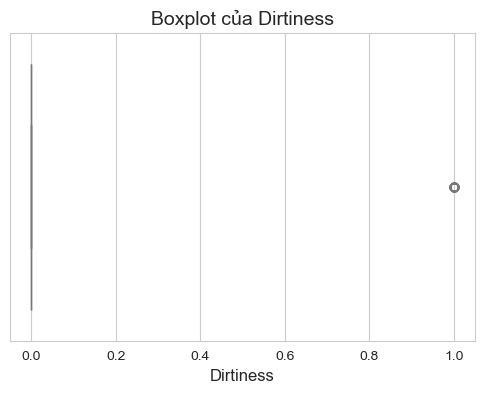

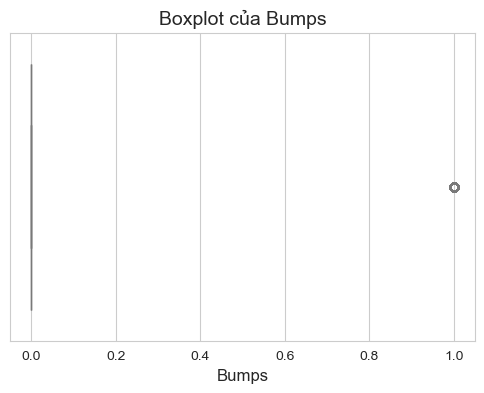

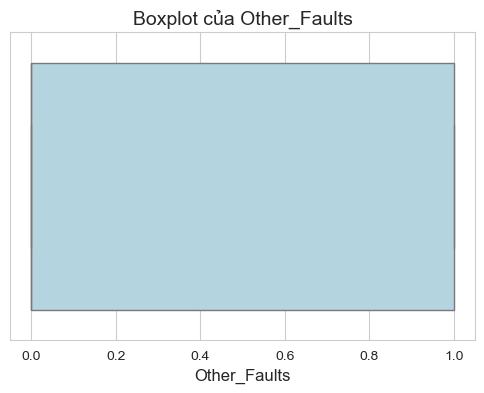

In [11]:
sns.set_style('whitegrid')

for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, color='lightblue')  # Boxplot cho từng cột số
    plt.title(f"Boxplot của {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.show()


Biểu đồ đếm

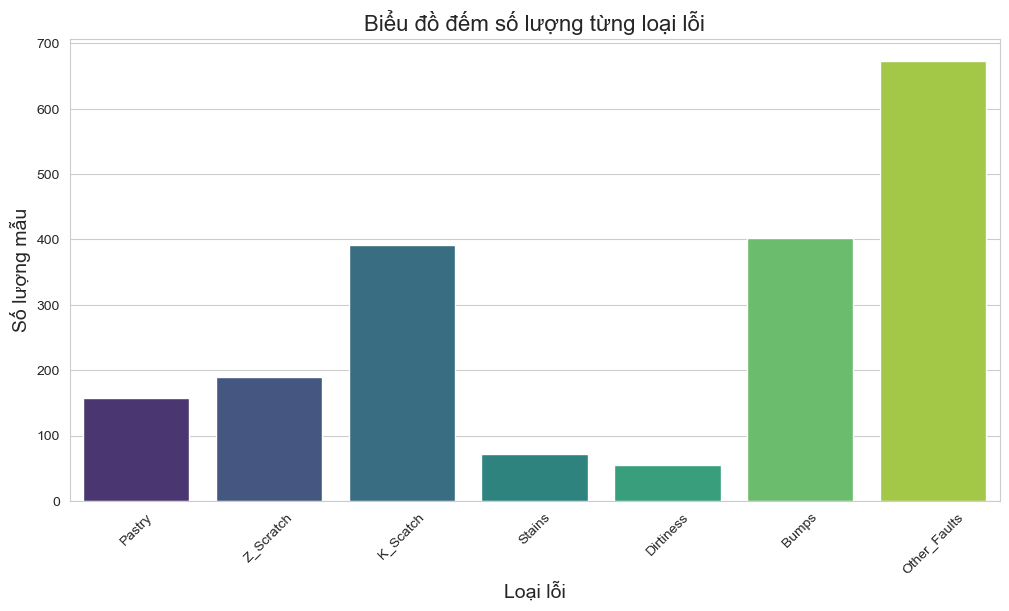

In [12]:
# Các cột lỗi trong dataset
fault_columns = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
                 'Dirtiness', 'Bumps', 'Other_Faults']

# Tạo cột phân loại lỗi (mỗi dòng có 1 lỗi = 1)
df['Fault_Type'] = df[fault_columns].idxmax(axis=1)

# Vẽ biểu đồ đếm số lượng lỗi
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Fault_Type', hue='Fault_Type', palette="viridis",legend=False)

plt.title("Biểu đồ đếm số lượng từng loại lỗi", fontsize=16)
plt.xlabel("Loại lỗi", fontsize=14)
plt.ylabel("Số lượng mẫu", fontsize=14)
plt.xticks(rotation=45)

plt.show()

Ma trận tương quan của các biến số

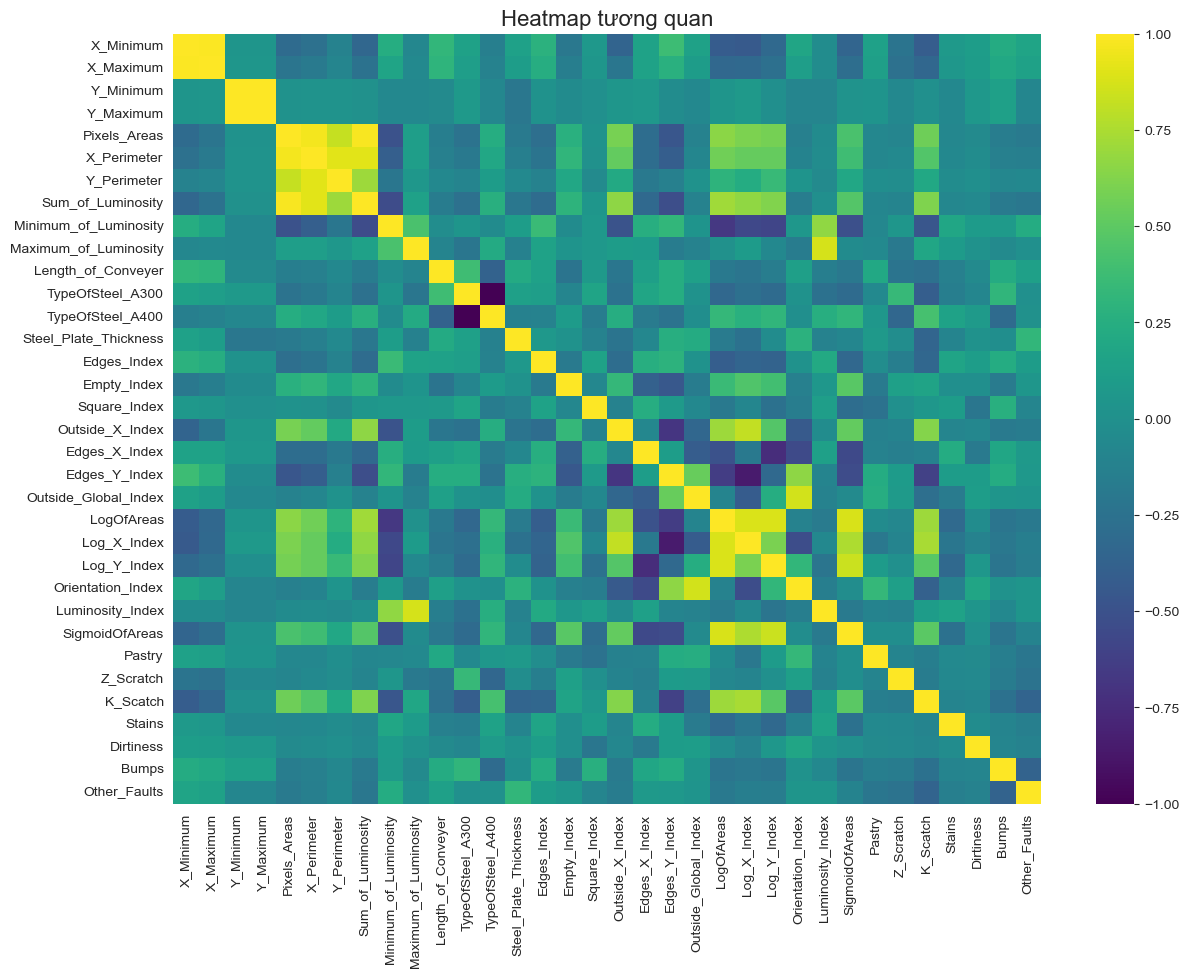

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='viridis')
plt.title("Heatmap tương quan", fontsize=16)
plt.show()


# Chuẩn bị dữ liệu

In [14]:
# Tách features và target
# Loại bỏ các cột one-hot lỗi khỏi X
X = df.drop(columns=fault_columns + ['Fault_Type'])
y = df['Fault_Type']

print("Số feature:", X.shape[1])
print("Các feature:", list(X.columns))

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuẩn hóa dữ liệu số
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nKích thước tập train/test:")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)


Số feature: 27
Các feature: ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']

Kích thước tập train/test:
X_train: (1552, 27)
X_test: (389, 27)


In [15]:
# Tạo cột Fault_Type (string)
df['Fault_Type'] = df[fault_columns].idxmax(axis=1)

# BỎ toàn bộ cột label để chỉ còn các feature numeric thật
X_features = df.drop(columns=fault_columns + ['Fault_Type'])

# Chạy KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_features)

# Chọn 2 feature để vẽ
feature_x = 'X_Minimum'
feature_y = 'Y_Minimum'

fig7 = px.scatter(
    X_features,
    x=feature_x,
    y=feature_y,
    color=clusters.astype(str),
    title=f"KMeans Clustering ({feature_x} vs {feature_y})",
    labels={feature_x: feature_x, feature_y: feature_y},
)

fig7.show()


In [16]:
if "Fault_Type" in df.columns:
    X = df.drop(columns=fault_columns + ["Fault_Type"])
else:
    X = df.drop(columns=fault_columns)

# Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df["anomaly"] = iso_forest.fit_predict(X)

# Chọn 2 feature để trực quan hóa
feature_x = "X_Minimum"
feature_y = "Y_Minimum"

fig8 = px.scatter(
    df,
    x=feature_x,
    y=feature_y,
    color=df["anomaly"].astype(str),
    title="Isolation Forest - Anomaly Detection",
    labels={feature_x: feature_x, feature_y: feature_y},
)

fig8.show()


# **Modeling**

## **With normal data**

### **Random Forest**

In [17]:

# Lưới tham số
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',  
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best F1 Score: 0.7997125932729803



Accuracy: 0.794344473007712

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.76      0.67      0.71        81
   Dirtiness       0.91      0.91      0.91        11
    K_Scatch       0.99      0.90      0.94        78
Other_Faults       0.70      0.84      0.76       135
      Pastry       0.59      0.53      0.56        32
      Stains       1.00      0.86      0.92        14
   Z_Scratch       0.97      0.87      0.92        38

    accuracy                           0.79       389
   macro avg       0.84      0.80      0.82       389
weighted avg       0.80      0.79      0.80       389



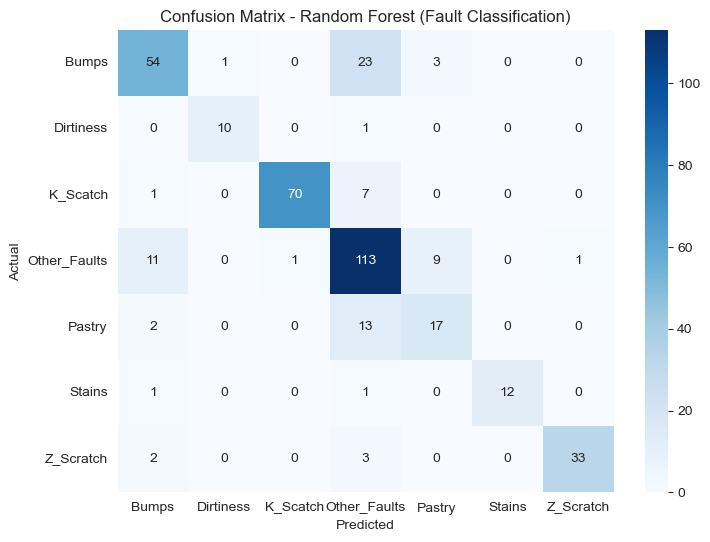

In [18]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred)
prec_rf = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_rf   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_,
            yticklabels=best_rf.classes_)
plt.title("Confusion Matrix - Random Forest (Fault Classification)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance - Random Forest:
                  Feature  Importance
10     Length_of_Conveyer    0.065769
21             LogOfAreas    0.063498
4            Pixels_Areas    0.062235
7       Sum_of_Luminosity    0.052640
17        Outside_X_Index    0.048930
8   Minimum_of_Luminosity    0.046108
24      Orientation_Index    0.044837
13  Steel_Plate_Thickness    0.044520
22            Log_X_Index    0.042980
0               X_Minimum    0.040714
1               X_Maximum    0.040211
16           Square_Index    0.039482
2               Y_Minimum    0.036616
14            Edges_Index    0.036131
26         SigmoidOfAreas    0.034363
3               Y_Maximum    0.033119
25       Luminosity_Index    0.031388
23            Log_Y_Index    0.029863
19          Edges_Y_Index    0.029238
5             X_Perimeter    0.027523
18          Edges_X_Index    0.026681
6             Y_Perimeter    0.025798
9   Maximum_of_Luminosity    0.025081
15            Empty_Index    0.024310
12       Type

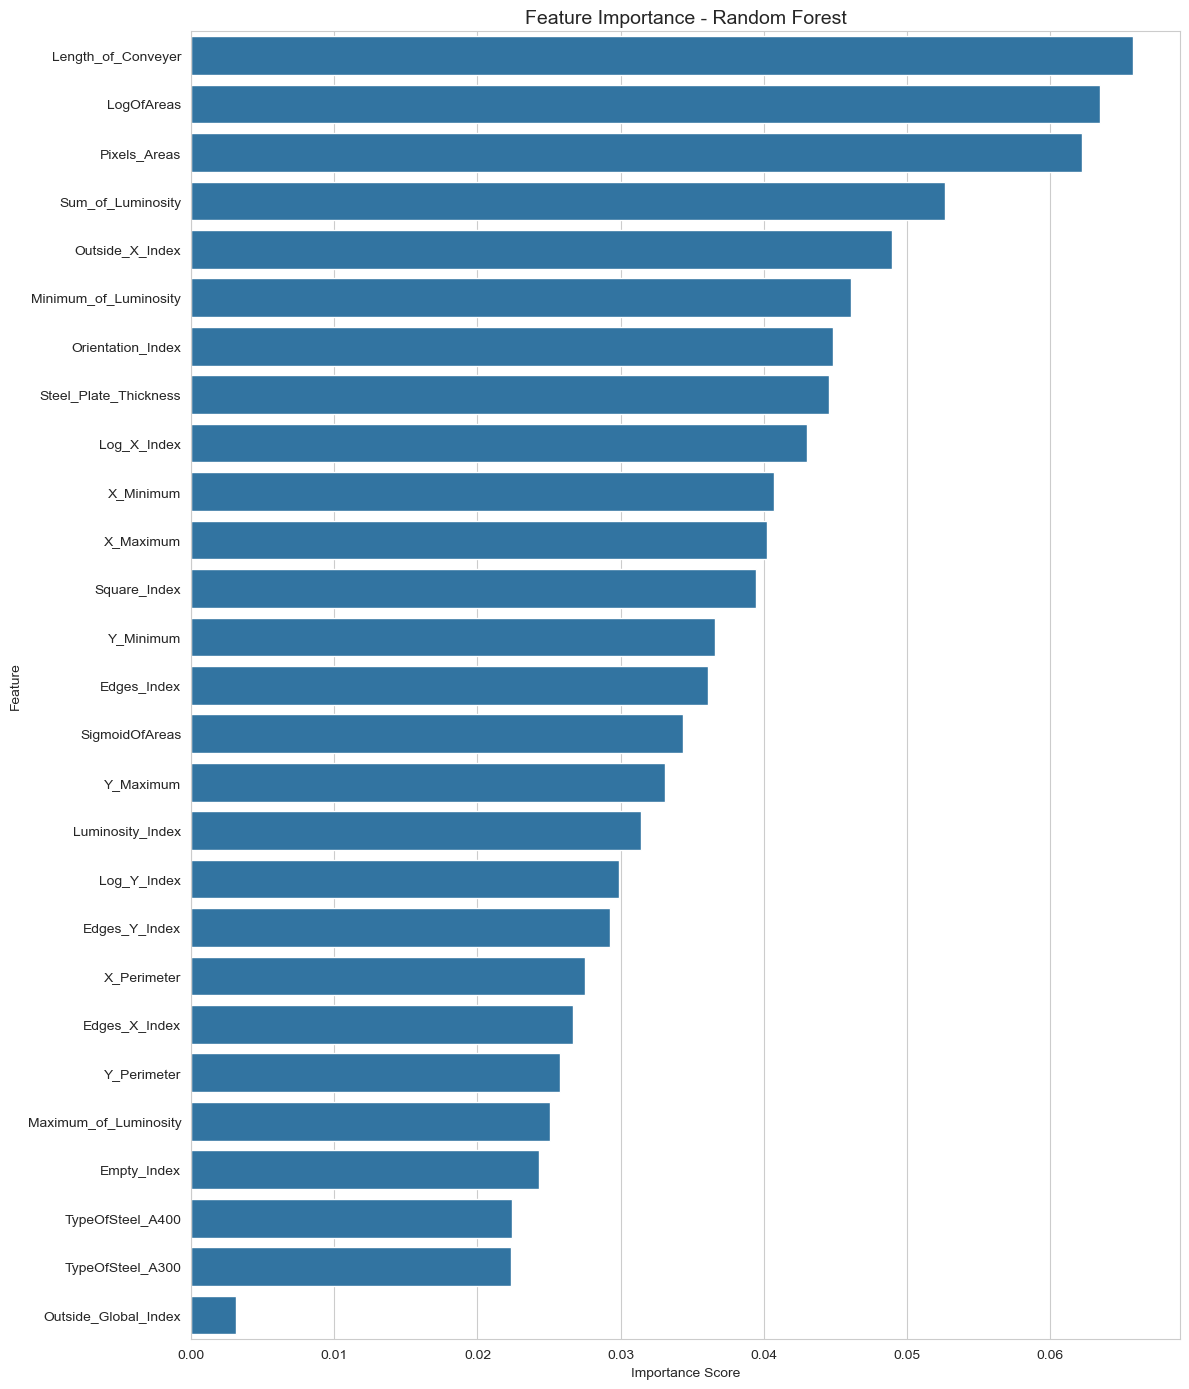

In [19]:
# Lấy tên cột trước khi scale
feature_names = X_train.columns

# Tạo DataFrame Feature Importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance - Random Forest:")
print(feature_importance)

# Vẽ biểu đồ
plt.figure(figsize=(12, 14))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



Accuracy sau khi lọc Top 20: 0.7712

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.70      0.62      0.66        81
   Dirtiness       1.00      0.91      0.95        11
    K_Scatch       0.99      0.91      0.95        78
Other_Faults       0.70      0.77      0.73       135
      Pastry       0.54      0.59      0.57        32
      Stains       1.00      0.86      0.92        14
   Z_Scratch       0.85      0.89      0.87        38

    accuracy                           0.77       389
   macro avg       0.83      0.79      0.81       389
weighted avg       0.78      0.77      0.77       389



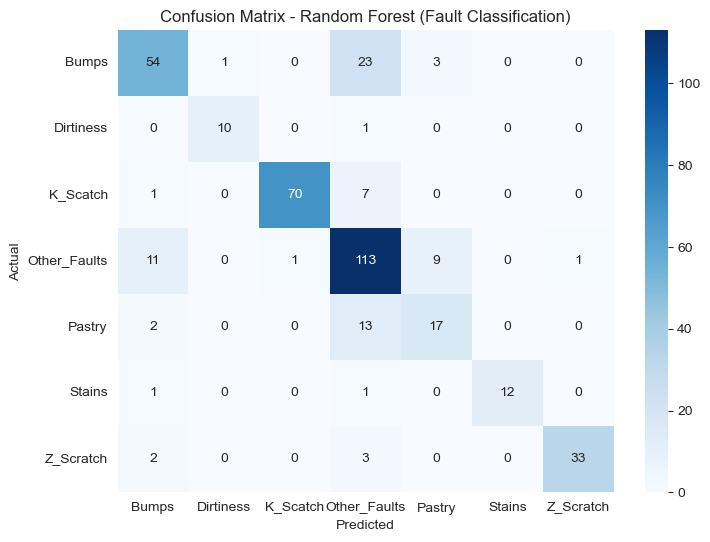

In [ ]:
# 1. Lấy top features
top_features = feature_importance.head(20)["Feature"].tolist()

# 2. Tạo tập dữ liệu mới (Sử dụng .copy() để tránh lỗi SettingWithCopyWarning)
X_train_top = X_train[top_features].copy()
X_test_top = X_test[top_features].copy()

# Scale lại dữ liệu trên 20 features này
X_train_top_scaled = scaler.fit_transform(X_train_top)
X_test_top_scaled = scaler.transform(X_test_top)

# 3. Huấn luyện lại model 
final_rf = RandomForestClassifier(
    **grid_search.best_params_, # Giải nén các tham số tốt nhất
    class_weight="balanced", 
    random_state=42
)

final_rf.fit(X_train_top_scaled, y_train)

# 4. Kiểm tra kết quả
y_pred_top = final_rf.predict(X_test_top_scaled)
print(f"Accuracy sau khi lọc Top 20: {accuracy_score(y_test, y_pred_top):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_top))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_,
            yticklabels=best_rf.classes_)
plt.title("Confusion Matrix - Random Forest (Fault Classification)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **Naive Bayes**

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Định nghĩa không gian tham số cho GaussianNB
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# Khởi tạo mô hình
nb_model = GaussianNB()

# Cấu hình GridSearchCV với cv=skf
grid_search_nb = GridSearchCV(
    estimator=nb_model, 
    param_grid=param_grid_nb, 
    cv=skf,             # Sử dụng StratifiedKFold ở đây
    verbose=1, 
    scoring='accuracy',
    n_jobs=-1           # Sử dụng toàn bộ nhân CPU để chạy nhanh hơn
)

# Huấn luyện
grid_search_nb.fit(X_train_scaled, y_train)

# Kết quả tối ưu
print(f"Tham số tốt nhất: {grid_search_nb.best_params_}")
print(f"Độ chính xác tốt nhất (CV): {grid_search_nb.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Tham số tốt nhất: {'var_smoothing': 0.0657933224657568}
Độ chính xác tốt nhất (CV): 0.6056


In [22]:
best_nb_model = grid_search_nb.best_estimator_
y_pred = best_nb_model.predict(X_test_scaled)

acc_nb  = accuracy_score(y_test, y_pred)
prec_nb = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_nb  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_nb   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nNaive Bayes Performance:")
print("Accuracy :", acc_nb)
print("Precision:", prec_nb)
print("Recall   :", rec_nb)
print("F1-score :", f1_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



Naive Bayes Performance:
Accuracy : 0.5912596401028277
Precision: 0.6647150663336278
Recall   : 0.5912596401028277
F1-score : 0.578422142074848

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.47      0.70      0.56        81
   Dirtiness       0.41      0.82      0.55        11
    K_Scatch       0.94      0.86      0.90        78
Other_Faults       0.69      0.24      0.36       135
      Pastry       0.29      0.62      0.40        32
      Stains       0.60      0.86      0.71        14
   Z_Scratch       0.84      0.84      0.84        38

    accuracy                           0.59       389
   macro avg       0.61      0.71      0.62       389
weighted avg       0.66      0.59      0.58       389



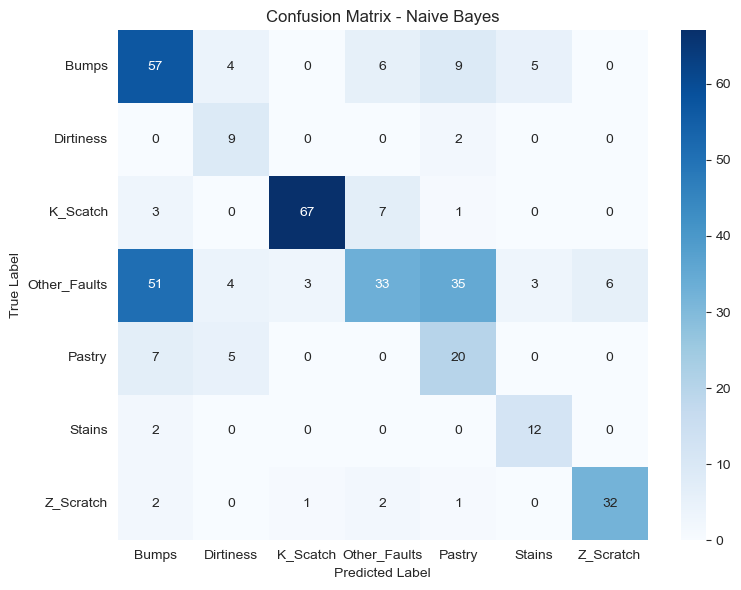

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

classes = np.unique(y_test)   # Lấy danh sách các lớp thật

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### **SVM**

In [24]:
# 1. Khởi tạo StratifiedKFold (giữ nguyên random_state=42 như trước)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Định nghĩa không gian tham số
# Thường dùng thang log để bao phủ dải rộng các giá trị
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# 3. Khởi tạo mô hình SVC
# Giữ các setting quan trọng của bạn: probability=True, class_weight='balanced'
svm_base = SVC(
    probability=True, 
    class_weight='balanced', 
    random_state=42
)

# 4. Cấu hình GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=skf,
    scoring='f1_weighted', # Dùng f1_weighted sẽ tốt hơn nếu data bị lệch class
    verbose=1,
    n_jobs=-1
)

# 5. Huấn luyện
grid_search_svm.fit(X_train_scaled, y_train)

# 6. Lấy mô hình tốt nhất
best_svm_model = grid_search_svm.best_estimator_

print(f"Tham số tốt nhất: {grid_search_svm.best_params_}")
print(f"F1-score tốt nhất (CV): {grid_search_svm.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tham số tốt nhất: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
F1-score tốt nhất (CV): 0.7529


In [25]:
# Dự đoán
y_pred = best_svm_model.predict(X_test_scaled)

# Đánh giá
acc_svm  = accuracy_score(y_test, y_pred)
prec_svm = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_svm  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_svm   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-score :", f1_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.7532133676092545
Precision: 0.7619077783574513
Recall   : 0.7532133676092545
F1-score : 0.754587134287637

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.63      0.70      0.67        81
   Dirtiness       1.00      0.91      0.95        11
    K_Scatch       0.97      0.95      0.96        78
Other_Faults       0.74      0.63      0.68       135
      Pastry       0.51      0.66      0.58        32
      Stains       0.80      0.86      0.83        14
   Z_Scratch       0.81      0.89      0.85        38

    accuracy                           0.75       389
   macro avg       0.78      0.80      0.79       389
weighted avg       0.76      0.75      0.75       389



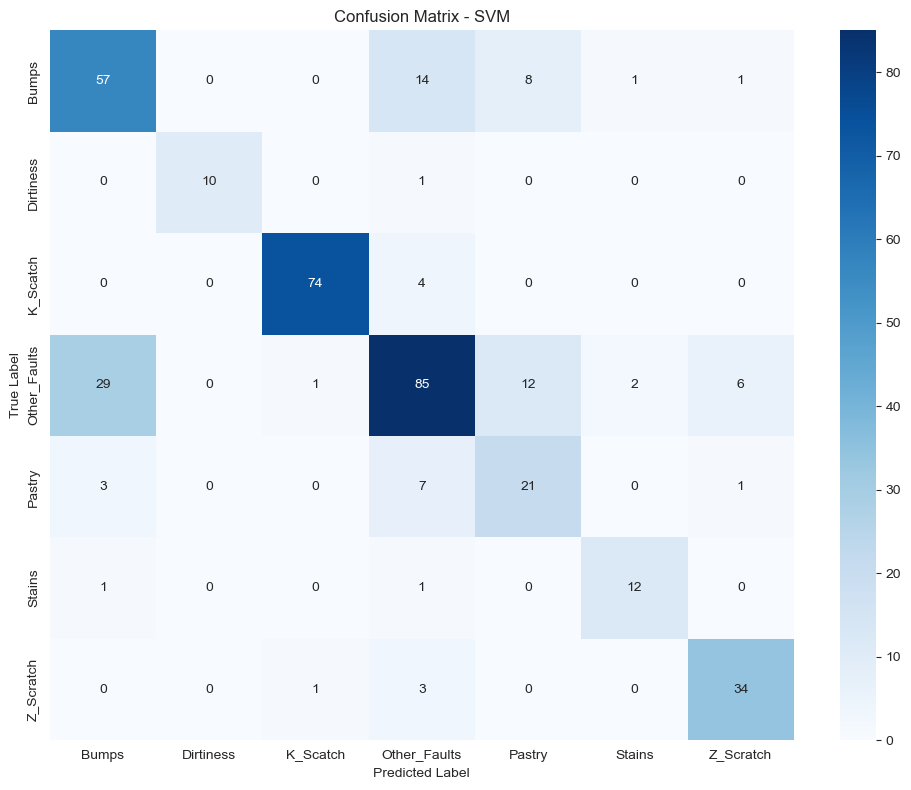

In [26]:
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### **ANN (MLP)**


In [27]:
# Encode multiclass labels
le = LabelEncoder()
y_train_ann = le.fit_transform(y_train)
y_test_ann  = le.transform(y_test)

# Convert type
X_train_ann = X_train_scaled.astype(np.float32)
X_test_ann  = X_test_scaled.astype(np.float32)
y_train_ann = y_train_ann.astype(np.int32)
y_test_ann  = y_test_ann.astype(np.int32)

num_classes = len(np.unique(y_train_ann))
input_dim = X_train_ann.shape[1]

print("Số lớp:", num_classes)
print("Số features:", input_dim)

Số lớp: 7
Số features: 27


In [28]:


# 1. Xây dựng mô hình ANN với tham số mới
ann_model = Sequential()
ann_model.add(Input(shape=(input_dim,)))

# Layer 1: 64 neurons, Dropout 0.1
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dropout(0.1)) # Cập nhật từ 0.2 -> 0.1

# Layer 2: 32 neurons, Dropout 0.1
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.1)) # Cập nhật từ 0.2 -> 0.1

# Output Layer cho nhiều lớp
ann_model.add(Dense(num_classes, activation='softmax'))

# 2. Compile model
# Sử dụng optimizer 'adam' như yêu cầu
ann_model.compile(
    optimizer=Adam(), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# 3. Huấn luyện với epochs và batch_size mới
history = ann_model.fit(
    X_train_ann, y_train_ann,
    validation_split=0.2,
    epochs=100,      # Cập nhật từ 60 -> 100
    batch_size=64,   # Cập nhật từ 32 -> 64
    verbose=1
)

# 4. Dự đoán
y_pred_prob = ann_model.predict(X_test_ann)
y_pred = np.argmax(y_pred_prob, axis=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,103 (16.03 KB)

 Trainable params: 4,103 (16.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2084 - loss: 1.8519 - val_accuracy: 0.4534 - val_loss: 1.4995
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4843 - loss: 1.4265 - val_accuracy: 0.5305 - val_loss: 1.3420
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5454 - loss: 1.2710 - val_accuracy: 0.5981 - val_loss: 1.2220
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6032 - loss: 1.1376 - val_accuracy: 0.6270 - val_loss: 1.1272
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6008 - loss: 1.0684 - val_accuracy: 0.6334 - val_loss: 1.0584
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6314 - loss: 1.0074 - val_accuracy: 0.6367 - val_loss: 0.9896
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6516 - loss: 0.9109 - val_accuracy: 0.6720 - val_loss: 0.9255
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6687 - loss: 0.9056 - val_accuracy: 0.6881 - 

Accuracy: 0.7634961439588689
Precision: 0.7645551387418245
Recall: 0.7634961439588689
F1 Score: 0.7630648284012437

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.67      0.72      0.69        81
   Dirtiness       1.00      0.73      0.84        11
    K_Scatch       0.95      0.95      0.95        78
Other_Faults       0.71      0.70      0.71       135
      Pastry       0.55      0.50      0.52        32
      Stains       0.80      0.86      0.83        14
   Z_Scratch       0.87      0.89      0.88        38

    accuracy                           0.76       389
   macro avg       0.79      0.76      0.78       389
weighted avg       0.76      0.76      0.76       389



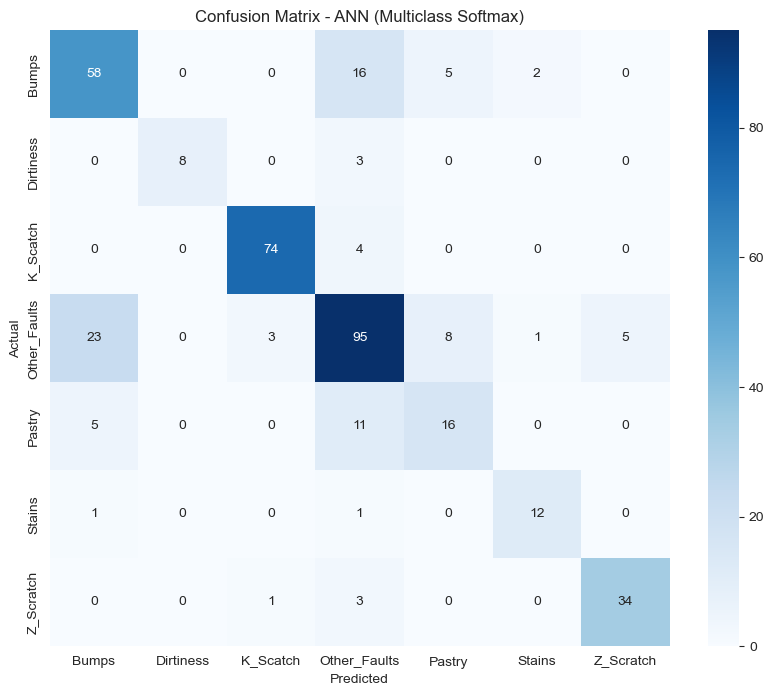

In [29]:
# Evaluation
acc_ann = accuracy_score(y_test_ann, y_pred)
prec_ann = precision_score(y_test_ann, y_pred, average="weighted", zero_division=0)
rec_ann = recall_score(y_test_ann, y_pred, average="weighted", zero_division=0)
f1_ann = f1_score(y_test_ann, y_pred, average="weighted", zero_division=0)

print("Accuracy:", acc_ann)
print("Precision:", prec_ann)
print("Recall:", rec_ann)
print("F1 Score:", f1_ann)

print("\nClassification Report:")
print(classification_report(y_test_ann, y_pred, target_names=le.classes_, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test_ann, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - ANN (Multiclass Softmax)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

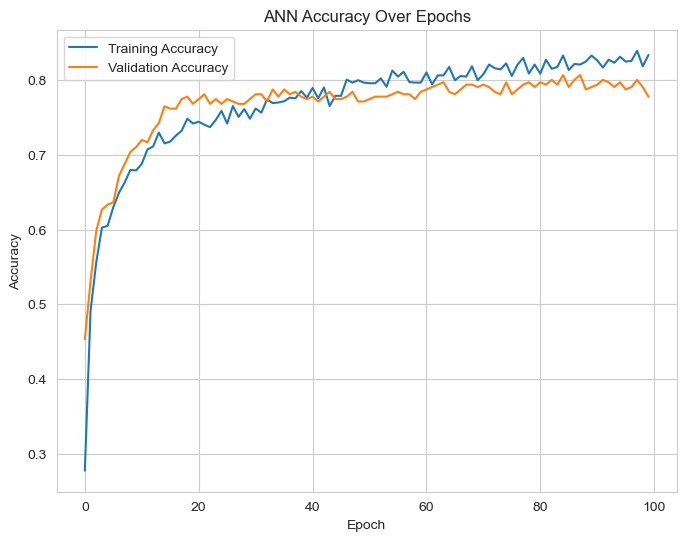

In [30]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("ANN Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### **LSTM**


In [ ]:
# Encode multiclass labels
le = LabelEncoder()
y_train_lstm = le.fit_transform(y_train)
y_test_lstm  = le.transform(y_test)

# Convert type
X_train_lstm = X_train_scaled.astype(np.float32)
X_test_lstm  = X_test_scaled.astype(np.float32)

# Reshape cho LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], 1, X_train_lstm.shape[1]))
X_test_lstm  = X_test_lstm.reshape((X_test_lstm.shape[0], 1, X_test_lstm.shape[1]))

num_classes = len(np.unique(y_train_lstm))
input_dim = X_train_lstm.shape[2]

print("Số lớp:", num_classes)
print("Số features:", input_dim)


Số lớp: 7
Số features: 27


In [32]:
# Xây dựng mô hình LSTM 
model = Sequential([
    Input(shape=(1, input_dim)),
    
    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')  # multiclass
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(0.001),
    metrics=['accuracy']
)

model.summary()

# Huấn luyện
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Dự đoán
y_pred_prob = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        79,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,895 (523.03 KB)

 Trainable params: 133,895 (523.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.2792 - loss: 1.9247 - val_accuracy: 0.4855 - val_loss: 1.8199
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4846 - loss: 1.7405 - val_accuracy: 0.4695 - val_loss: 1.5087
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4802 - loss: 1.4329 - val_accuracy: 0.4920 - val_loss: 1.3760
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5259 - loss: 1.2097 - val_accuracy: 0.5691 - val_loss: 1.2259
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5521 - loss: 1.1110 - val_accuracy: 0.6206 - val_loss: 1.1060
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5843 - loss: 1.0210 - val_accuracy: 0.6302 - val_loss: 1.0257
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6261 - loss: 0.9621 - val_accuracy: 0.6463 - val_loss: 0.9695
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6456 - loss: 0.9097 - val_accuracy: 0.6559 - val_loss

Accuracy: 0.7686375321336761

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.71      0.72      0.71        81
   Dirtiness       0.80      0.73      0.76        11
    K_Scatch       0.96      0.96      0.96        78
Other_Faults       0.73      0.67      0.70       135
      Pastry       0.58      0.69      0.63        32
      Stains       0.75      0.86      0.80        14
   Z_Scratch       0.81      0.89      0.85        38

    accuracy                           0.77       389
   macro avg       0.76      0.79      0.77       389
weighted avg       0.77      0.77      0.77       389



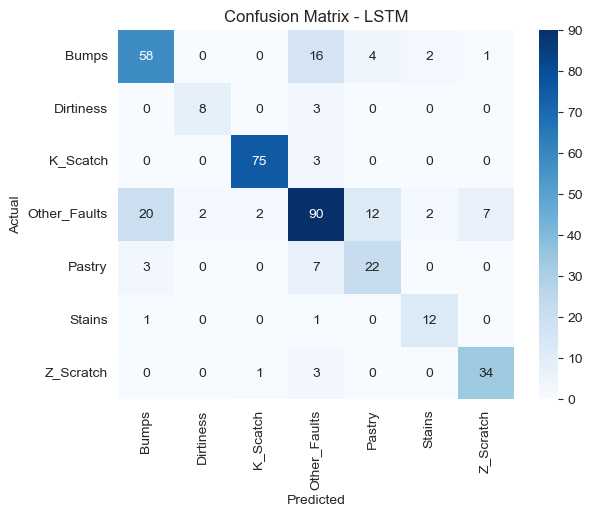

In [33]:
# Evaluation
acc_lstm = accuracy_score(y_test_lstm, y_pred)
prec_lstm = precision_score(y_test_lstm, y_pred, average="weighted", zero_division=0)
rec_lstm = recall_score(y_test_lstm, y_pred, average="weighted", zero_division=0)
f1_lstm = f1_score(y_test_lstm, y_pred, average="weighted", zero_division=0)

print("Accuracy:", acc_lstm)
print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred, target_names=le.classes_, zero_division=0))
 
# Confusion Matrix
cm = confusion_matrix(y_test_lstm, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [34]:
# Vẽ biểu đồ accuracy
fig10 = go.Figure()
fig10.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines', name='Training Accuracy'))
fig10.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines', name='Validation Accuracy'))
fig10.update_layout(title="LSTM Accuracy Over Epochs", xaxis_title="Epoch", yaxis_title="Accuracy")
fig10.show()

### So sánh kết quả các mô hình


           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.794344   0.804369  0.794344  0.795650
1    Naive Bayes  0.591260   0.664715  0.591260  0.578422
2            SVM  0.753213   0.761908  0.753213  0.754587
3            ANN  0.763496   0.764555  0.763496  0.763065
4           LSTM  0.768638   0.770338  0.768638  0.768189


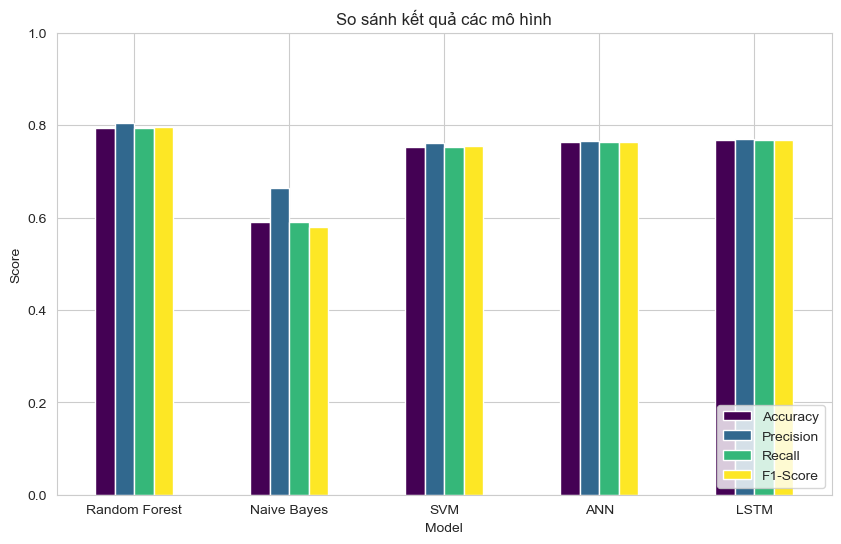

In [35]:
# Tạo bảng kết quả
results = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes", "SVM", "ANN", "LSTM"],
    "Accuracy": [acc_rf, acc_nb, acc_svm, acc_ann, acc_lstm],
    "Precision": [prec_rf, prec_nb, prec_svm, prec_ann, prec_lstm],
    "Recall": [rec_rf, rec_nb, rec_svm, rec_ann, rec_lstm],
    "F1-Score": [f1_rf, f1_nb, f1_svm, f1_ann, f1_lstm]
})

print(results)

# Vẽ biểu đồ so sánh
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(10,6), colormap="viridis", rot=0
)

plt.title("So sánh kết quả các mô hình")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


## **With smoted data**

In [36]:
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, y_train.shape)
print("After  SMOTE:", X_train_smote.shape, y_train_smote.shape)

# Scale lại dữ liệu sau SMOTE
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

Before SMOTE: (1552, 27) (1552,)
After  SMOTE: (3766, 27) (3766,)


### **Random Forest**

In [37]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',    # phù hợp cho multiclass không cân bằng
    cv=skf,
    n_jobs=-1,
    verbose=2
)

# Train bằng TRAIN + SMOTE
grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# Lấy model tốt nhất
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Score: 0.911090049136428



Accuracy: 0.7994858611825193

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.73      0.77      0.75        81
   Dirtiness       1.00      0.91      0.95        11
    K_Scatch       0.97      0.92      0.95        78
Other_Faults       0.78      0.73      0.75       135
      Pastry       0.52      0.72      0.61        32
      Stains       0.86      0.86      0.86        14
   Z_Scratch       0.92      0.89      0.91        38

    accuracy                           0.80       389
   macro avg       0.83      0.83      0.82       389
weighted avg       0.81      0.80      0.80       389



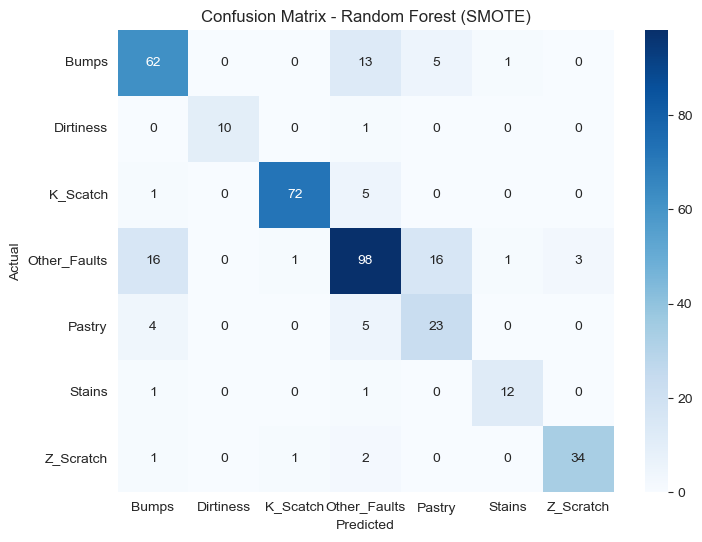

In [38]:
y_pred = best_rf.predict(X_test)   

acc_rf_sm  = accuracy_score(y_test, y_pred)
prec_rf_sm = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_rf_sm  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_rf_sm   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nAccuracy:", acc_rf_sm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)

plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance - Random Forest (SMOTE):
                  Feature  Importance
10     Length_of_Conveyer    0.076136
21             LogOfAreas    0.060249
4            Pixels_Areas    0.059815
17        Outside_X_Index    0.045272
16           Square_Index    0.043499
8   Minimum_of_Luminosity    0.042961
13  Steel_Plate_Thickness    0.042939
22            Log_X_Index    0.042878
2               Y_Minimum    0.040526
7       Sum_of_Luminosity    0.040283
24      Orientation_Index    0.039907
0               X_Minimum    0.039395
26         SigmoidOfAreas    0.037881
1               X_Maximum    0.037542
3               Y_Maximum    0.036626
14            Edges_Index    0.034940
12       TypeOfSteel_A400    0.032762
23            Log_Y_Index    0.032262
19          Edges_Y_Index    0.031735
25       Luminosity_Index    0.031701
5             X_Perimeter    0.031508
6             Y_Perimeter    0.028472
9   Maximum_of_Luminosity    0.023102
15            Empty_Index    0.023039
18   

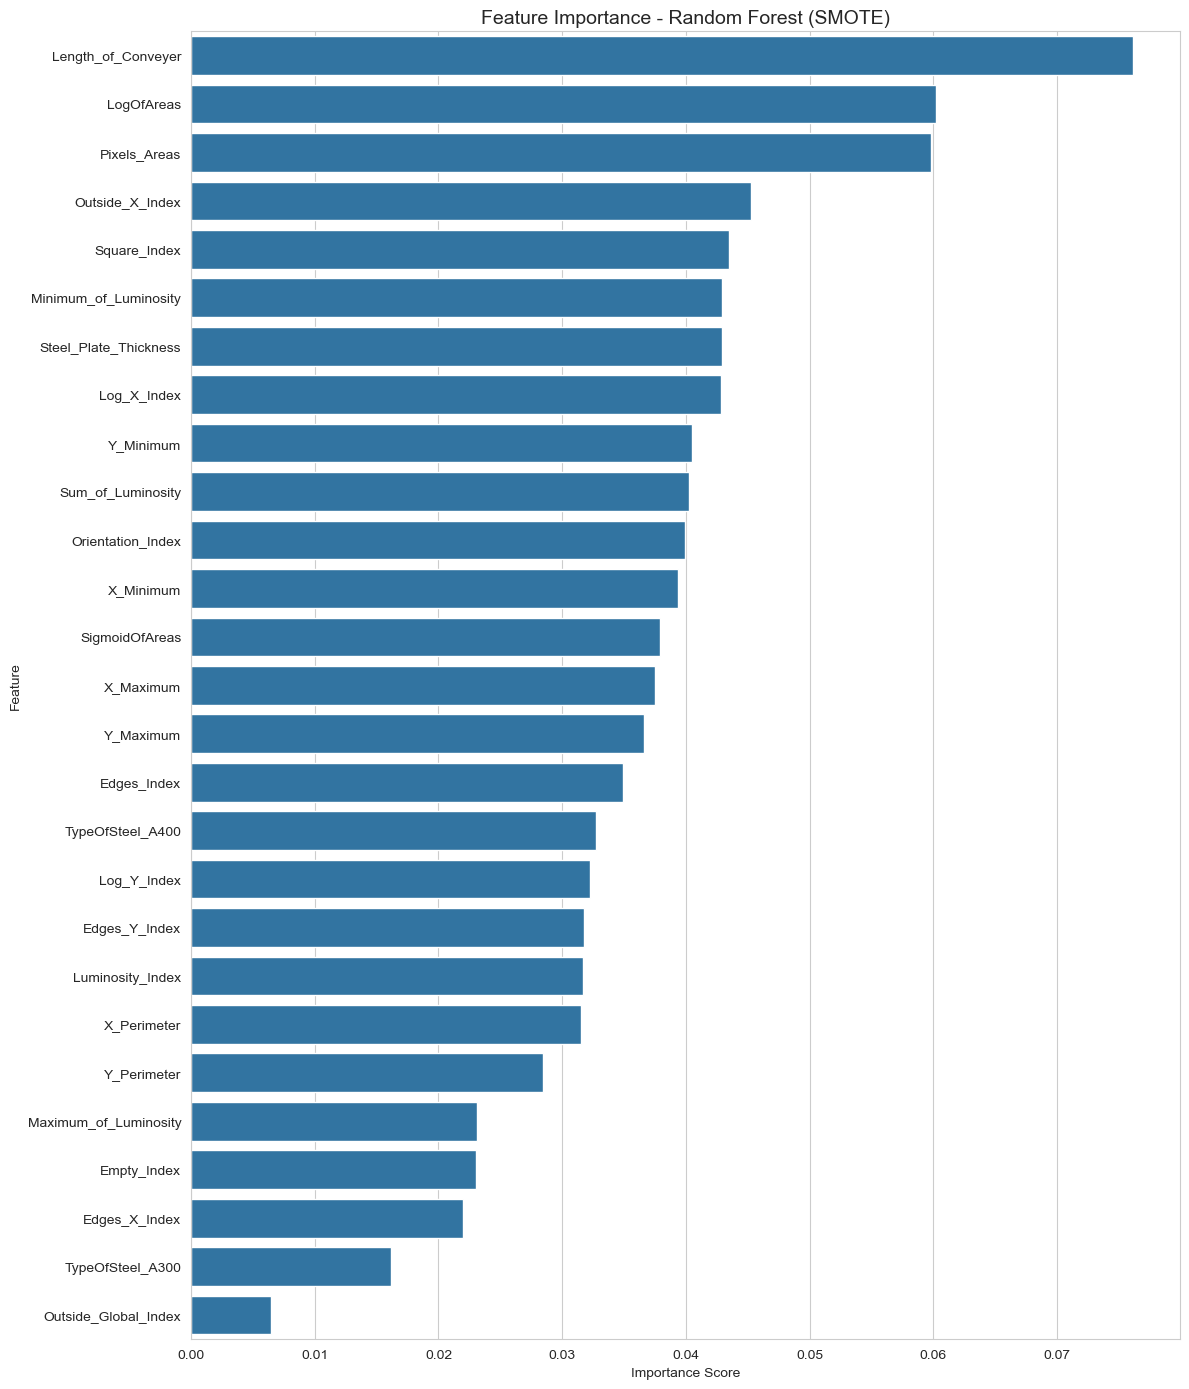

In [39]:
# FEATURE IMPORTANCE
feature_names = X_train.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance - Random Forest (SMOTE):")
print(feature_importance)

plt.figure(figsize=(12, 14))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - Random Forest (SMOTE)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### **Naive Bayes**

In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Định nghĩa không gian tham số cho GaussianNB
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 3. Khởi tạo mô hình
nb_model = GaussianNB()

# 4. Cấu hình GridSearchCV với cv=skf
grid_search_nb = GridSearchCV(
    estimator=nb_model, 
    param_grid=param_grid_nb, 
    cv=skf,             # Sử dụng StratifiedKFold ở đây
    verbose=1, 
    scoring='accuracy',
    n_jobs=-1           # Sử dụng toàn bộ nhân CPU để chạy nhanh hơn
)

# 5. Huấn luyện
grid_search_nb.fit(X_train_smote_scaled, y_train_smote)
best_nb_model = grid_search_nb.best_estimator_
# 6. Kết quả tối ưu
print(f"Tham số tốt nhất: {grid_search_nb.best_params_}")
print(f"Độ chính xác tốt nhất (CV): {grid_search_nb.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Tham số tốt nhất: {'var_smoothing': 0.012328467394420659}
Độ chính xác tốt nhất (CV): 0.7533



Naive Bayes Performance (Optimized SMOTE):
Accuracy : 0.6195372750642674
Precision: 0.6970166738163195
Recall   : 0.6195372750642674
F1-score : 0.6125437357628652

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.49      0.72      0.58        81
   Dirtiness       0.33      0.82      0.47        11
    K_Scatch       0.97      0.88      0.93        78
Other_Faults       0.72      0.29      0.41       135
      Pastry       0.35      0.72      0.47        32
      Stains       0.71      0.86      0.77        14
   Z_Scratch       0.89      0.82      0.85        38

    accuracy                           0.62       389
   macro avg       0.64      0.73      0.64       389
weighted avg       0.70      0.62      0.61       389



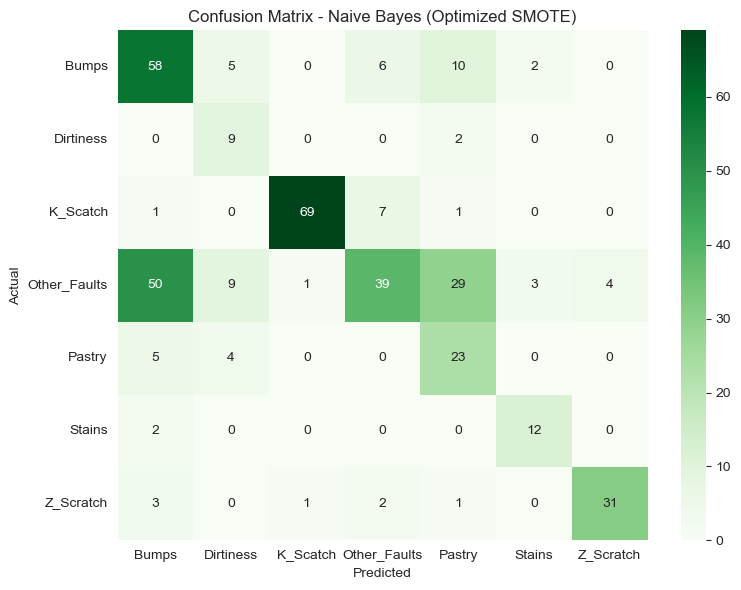

In [41]:
y_pred = best_nb_model.predict(X_test_scaled)
# Tính các metrics
acc_nb_sm  = accuracy_score(y_test, y_pred)
prec_nb_sm = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_nb_sm  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_nb_sm   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nNaive Bayes Performance (Optimized SMOTE):")
print("Accuracy :", acc_nb_sm)
print("Precision:", prec_nb_sm)
print("Recall   :", rec_nb_sm)
print("F1-score :", f1_nb_sm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix - Naive Bayes (Optimized SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### **SVM**

In [42]:
# 1. Khởi tạo StratifiedKFold (giữ nguyên random_state=42 như trước)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Định nghĩa không gian tham số
# Thường dùng thang log để bao phủ dải rộng các giá trị
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# 3. Khởi tạo mô hình SVC
# Giữ các setting quan trọng của bạn: probability=True, class_weight='balanced'
svm_base = SVC(
    probability=True, 
    class_weight='balanced', 
    random_state=42
)

# 4. Cấu hình GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=skf,
    scoring='f1_weighted', # Dùng f1_weighted sẽ tốt hơn nếu data bị lệch class
    verbose=1,
    n_jobs=-1
)

# 5. Huấn luyện
grid_search_svm.fit(X_train_smote_scaled, y_train_smote)

# 6. Lấy mô hình tốt nhất
best_svm_model = grid_search_svm.best_estimator_

print(f"Tham số tốt nhất: {grid_search_svm.best_params_}")
print(f"F1-score tốt nhất (CV): {grid_search_svm.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tham số tốt nhất: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
F1-score tốt nhất (CV): 0.9147



SVM Performance (After SMOTE):
Accuracy : 0.7506426735218509
Precision: 0.753111778424305
Recall   : 0.7506426735218509
F1-score : 0.7514366262958166

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.64      0.68      0.66        81
   Dirtiness       1.00      0.91      0.95        11
    K_Scatch       0.96      0.94      0.95        78
Other_Faults       0.71      0.67      0.69       135
      Pastry       0.55      0.56      0.55        32
      Stains       0.80      0.86      0.83        14
   Z_Scratch       0.82      0.87      0.85        38

    accuracy                           0.75       389
   macro avg       0.78      0.78      0.78       389
weighted avg       0.75      0.75      0.75       389



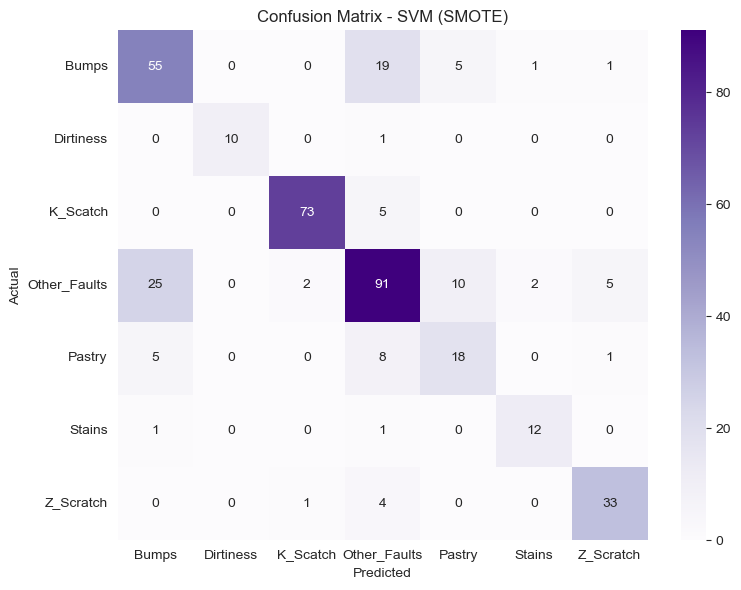

In [43]:
# Dự đoán
y_pred = best_svm_model.predict(X_test_scaled)
# Evaluation (multiclass-safe)
acc_svm_sm  = accuracy_score(y_test, y_pred)
prec_svm_sm = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_svm_sm  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_svm_sm   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nSVM Performance (After SMOTE):")
print("Accuracy :", acc_svm_sm)
print("Precision:", prec_svm_sm)
print("Recall   :", rec_svm_sm)
print("F1-score :", f1_svm_sm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)

plt.title("Confusion Matrix - SVM (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### **ANN(MLP)**

In [44]:
le = LabelEncoder()

y_train_ann = le.fit_transform(y_train_smote)
y_test_ann  = le.transform(y_test)

# Convert dtype cho TensorFlow
X_train_ann = X_train_smote_scaled.astype(np.float32)
X_test_ann  = X_test_scaled.astype(np.float32)
y_train_ann = y_train_ann.astype(np.int32)
y_test_ann  = y_test_ann.astype(np.int32)

num_classes = len(np.unique(y_train_ann))
input_dim = X_train_ann.shape[1]

print("Số lớp:", num_classes)
print("Số features:", input_dim)


Số lớp: 7
Số features: 27


In [45]:


# 1. Xây dựng mô hình ANN với tham số mới
ann_model = Sequential()
ann_model.add(Input(shape=(input_dim,)))

# Layer 1: 64 neurons, Dropout 0.1
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dropout(0.1)) # Cập nhật từ 0.2 -> 0.1

# Layer 2: 32 neurons, Dropout 0.1
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.1)) # Cập nhật từ 0.2 -> 0.1

# Output Layer cho nhiều lớp
ann_model.add(Dense(num_classes, activation='softmax'))

# 2. Compile model
# Sử dụng optimizer 'adam' như yêu cầu
ann_model.compile(
    optimizer=Adam(), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# 3. Huấn luyện với epochs và batch_size mới
history = ann_model.fit(
    X_train_ann, y_train_ann,
    validation_split=0.2,
    epochs=100,      # Cập nhật từ 60 -> 100
    batch_size=64,   # Cập nhật từ 32 -> 64
    verbose=1
)

# 4. Dự đoán
y_pred_prob = ann_model.predict(X_test_ann)
y_pred = np.argmax(y_pred_prob, axis=1)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,103 (16.03 KB)

 Trainable params: 4,103 (16.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3067 - loss: 1.7709 - val_accuracy: 0.3156 - val_loss: 1.7228
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6078 - loss: 1.1955 - val_accuracy: 0.5464 - val_loss: 1.0875
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7011 - loss: 0.8642 - val_accuracy: 0.8422 - val_loss: 0.7282
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7686 - loss: 0.7030 - val_accuracy: 0.9164 - val_loss: 0.4907
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7842 - loss: 0.6473 - val_accuracy: 0.9218 - val_loss: 0.4550
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7707 - loss: 0.6106 - val_accuracy: 0.9257 - val_loss: 0.3519
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7979 - loss: 0.5689 - val_accuracy: 0.9297 - val_loss: 0.3244
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7888 - loss: 0.5564 - val_accuracy: 0.9297

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

ANN Performance (SMOTE):
Accuracy : 0.7660668380462725
Precision: 0.7686988903442006
Recall   : 0.7660668380462725
F1-score : 0.766293777442821

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.68      0.74      0.71        81
   Dirtiness       0.83      0.91      0.87        11
    K_Scatch       0.97      0.95      0.96        78
Other_Faults       0.72      0.66      0.69       135
      Pastry       0.54      0.59      0.57        32
      Stains       0.75      0.86      0.80        14
   Z_Scratch       0.87      0.89      0.88        38

    accuracy                           0.77       389
   macro avg       0.77      0.80      0.78       389
weighted avg       0.77      0.77      0.77       389



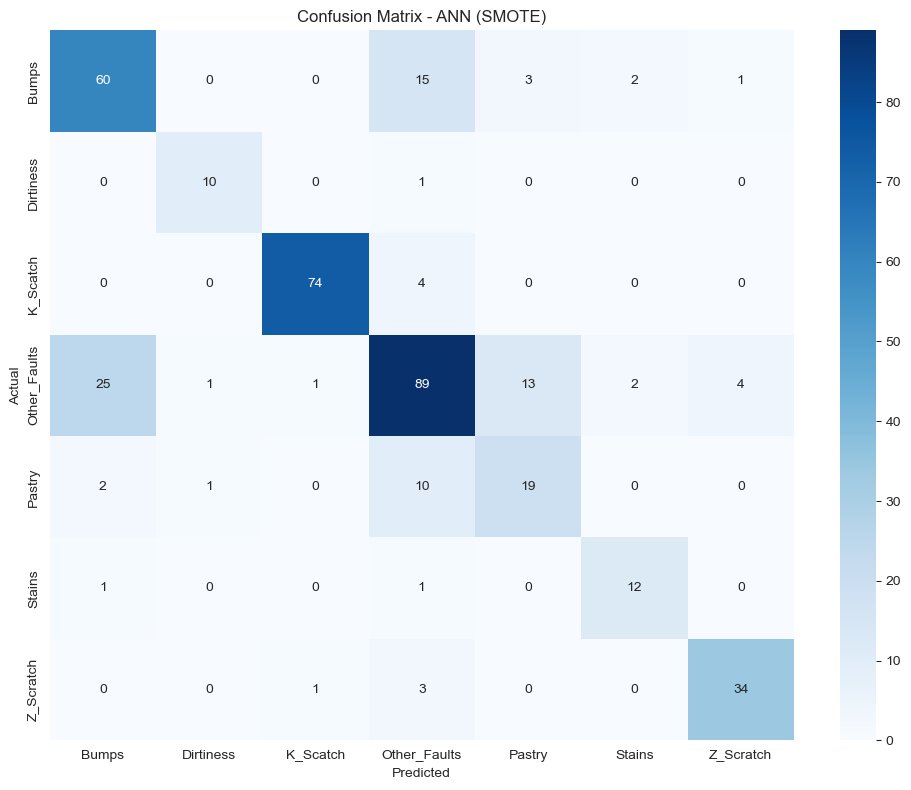

In [46]:
# Predict
y_pred_prob = ann_model.predict(X_test_ann)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
acc_ann_sm  = accuracy_score(y_test_ann, y_pred)
prec_ann_sm = precision_score(y_test_ann, y_pred, average="weighted", zero_division=0)
rec_ann_sm  = recall_score(y_test_ann, y_pred, average="weighted", zero_division=0)
f1_ann_sm   = f1_score(y_test_ann, y_pred, average="weighted", zero_division=0)

print("\nANN Performance (SMOTE):")
print("Accuracy :", acc_ann_sm)
print("Precision:", prec_ann_sm)
print("Recall   :", rec_ann_sm)
print("F1-score :", f1_ann_sm)

print("\nClassification Report:")
print(classification_report(
    y_test_ann,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))
cm = confusion_matrix(y_test_ann, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - ANN (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

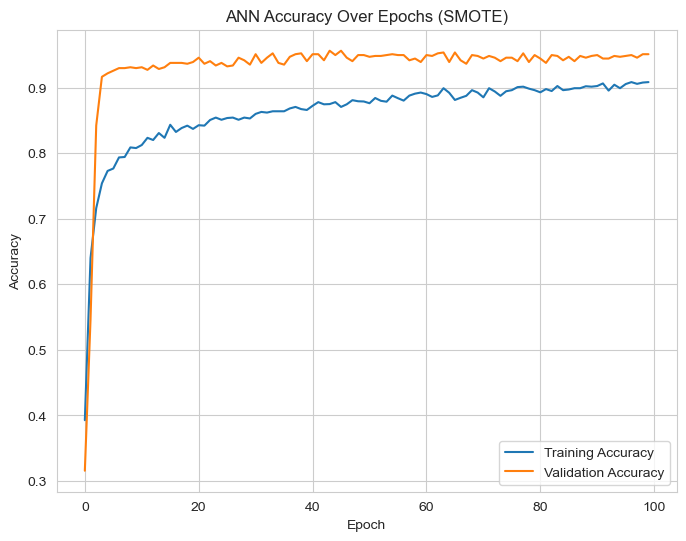

In [47]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("ANN Accuracy Over Epochs (SMOTE)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### **LSTM**

In [48]:
le = LabelEncoder()

y_train_lstm = le.fit_transform(y_train_smote)
y_test_lstm  = le.transform(y_test)

# Convert dtype
X_train_lstm = X_train_smote_scaled.astype(np.float32)
X_test_lstm  = X_test_scaled.astype(np.float32)

y_train_lstm = y_train_lstm.astype(np.int32)
y_test_lstm  = y_test_lstm.astype(np.int32)

# Reshape cho LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_lstm.reshape(
    (X_train_lstm.shape[0], 1, X_train_lstm.shape[1])
)
X_test_lstm = X_test_lstm.reshape(
    (X_test_lstm.shape[0], 1, X_test_lstm.shape[1])
)

num_classes = len(np.unique(y_train_lstm))
input_dim = X_train_lstm.shape[2]

print("Số lớp:", num_classes)
print("Số features:", input_dim)


Số lớp: 7
Số features: 27


In [49]:
model = Sequential([
    Input(shape=(1, input_dim)),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 128)         │        79,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,895 (523.03 KB)

 Trainable params: 133,895 (523.03 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,          
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.3843 - loss: 1.8444 - val_accuracy: 0.0000e+00 - val_loss: 2.0750
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5206 - loss: 1.2680 - val_accuracy: 0.0000e+00 - val_loss: 2.0317
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6487 - loss: 0.9469 - val_accuracy: 0.4801 - val_loss: 1.5187
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7018 - loss: 0.8199 - val_accuracy: 0.4881 - val_loss: 1.0451
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7432 - loss: 0.6890 - val_accuracy: 0.6857 - val_loss: 0.8087
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7633 - loss: 0.6512 - val_accuracy: 0.8316 - val_loss: 0.6477
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7714 - loss: 0.6129 - val_accuracy: 0.8939 - val_loss: 0.5397
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8017 - loss: 0.5846 - val_accuracy: 0

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step

LSTM Performance (SMOTE):
Accuracy : 0.7609254498714653
Precision: 0.771252434815052
Recall   : 0.7609254498714653
F1-score : 0.7630165818303017

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.67      0.72      0.69        81
   Dirtiness       0.83      0.91      0.87        11
    K_Scatch       0.97      0.95      0.96        78
Other_Faults       0.76      0.64      0.70       135
      Pastry       0.48      0.66      0.55        32
      Stains       0.80      0.86      0.83        14
   Z_Scratch       0.85      0.89      0.87        38

    accuracy                           0.76       389
   macro avg       0.77      0.80      0.78       389
weighted avg       0.77      0.76      0.76       389



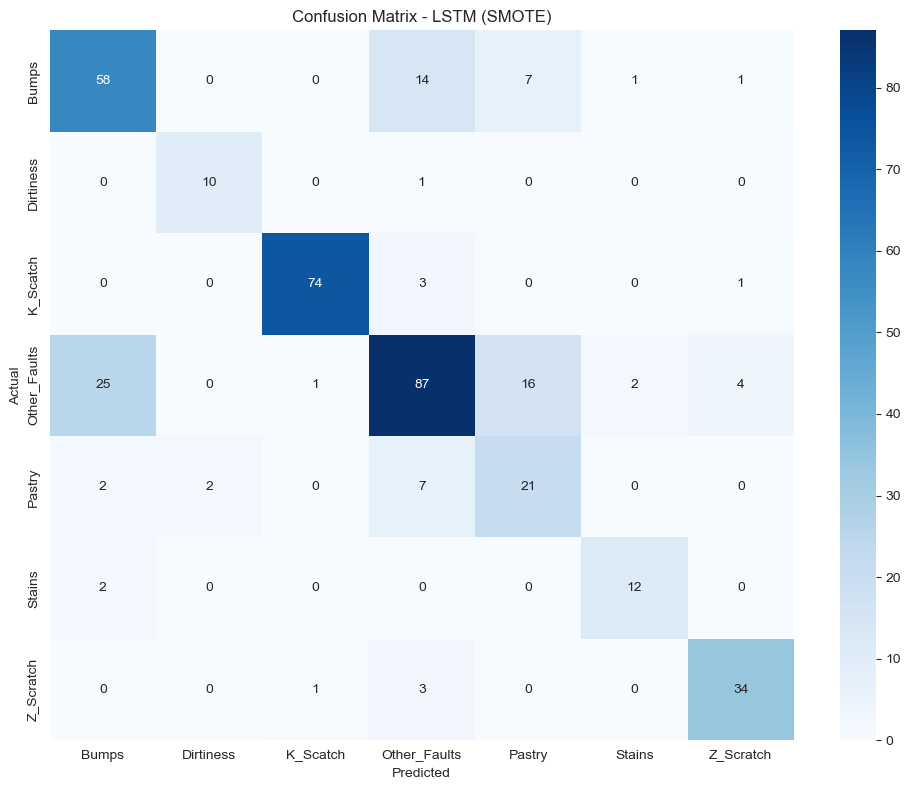

In [51]:
# Predict
y_pred_prob = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
acc_lstm_sm  = accuracy_score(y_test_lstm, y_pred)
prec_lstm_sm = precision_score(y_test_lstm, y_pred, average="weighted", zero_division=0)
rec_lstm_sm  = recall_score(y_test_lstm, y_pred, average="weighted", zero_division=0)
f1_lstm_sm   = f1_score(y_test_lstm, y_pred, average="weighted", zero_division=0)

print("\nLSTM Performance (SMOTE):")
print("Accuracy :", acc_lstm_sm)
print("Precision:", prec_lstm_sm)
print("Recall   :", rec_lstm_sm)
print("F1-score :", f1_lstm_sm)

print("\nClassification Report:")
print(classification_report(
    y_test_lstm,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test_lstm, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - LSTM (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



In [52]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    y=history.history['accuracy'],
    mode='lines',
    name='Training Accuracy'
))
fig.add_trace(go.Scatter(
    y=history.history['val_accuracy'],
    mode='lines',
    name='Validation Accuracy'
))

fig.update_layout(
    title="LSTM Accuracy Over Epochs (SMOTE)",
    xaxis_title="Epoch",
    yaxis_title="Accuracy"
)

fig.show()


### **So sánh kết quả các mô hình**

Bảng so sánh kết quả các mô hình (SMOTE)
           Model  Accuracy  Precision  Recall  F1-Score
0  Random Forest    0.7995     0.8110  0.7995    0.8033
1    Naive Bayes    0.6195     0.6970  0.6195    0.6125
2            SVM    0.7506     0.7531  0.7506    0.7514
3            ANN    0.7661     0.7687  0.7661    0.7663
4           LSTM    0.7609     0.7713  0.7609    0.7630


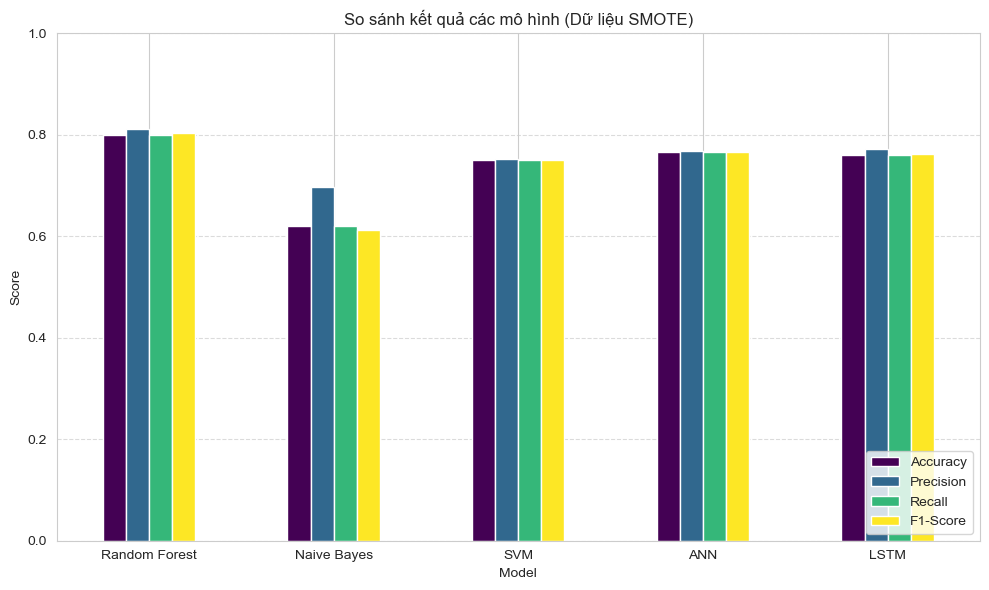

In [53]:
# Gom kết quả SMOTE
results_smote = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes", "SVM", "ANN", "LSTM"],
    "Accuracy":  [acc_rf_sm, acc_nb_sm, acc_svm_sm, acc_ann_sm, acc_lstm_sm],
    "Precision": [prec_rf_sm, prec_nb_sm, prec_svm_sm, prec_ann_sm, prec_lstm_sm],
    "Recall":    [rec_rf_sm, rec_nb_sm, rec_svm_sm, rec_ann_sm, rec_lstm_sm],
    "F1-Score":  [f1_rf_sm,  f1_nb_sm,  f1_svm_sm,  f1_ann_sm,  f1_lstm_sm]
})

# Làm tròn số liệu
results_smote[["Accuracy","Precision","Recall","F1-Score"]] = \
    results_smote[["Accuracy","Precision","Recall","F1-Score"]].round(4)

print("Bảng so sánh kết quả các mô hình (SMOTE)")
print(results_smote)

# Vẽ biểu đồ 
results_smote.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10,6),
    colormap="viridis",
    rot=0
)

plt.title("So sánh kết quả các mô hình (Dữ liệu SMOTE)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Using PCA**

In [54]:
# PCA
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Số feature ban đầu:", X_train_scaled.shape[1])
print("Số feature sau PCA:", X_train_pca.shape[1])
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Số feature ban đầu: 27
Số feature sau PCA: 12
Explained variance: 0.9548809127247424


### **Random Forest**

In [55]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',   # chuẩn cho multiclass
    cv=skf,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_pca, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-macro:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1-macro: 0.7622608950818911


Accuracy : 0.7506426735218509
Precision: 0.7692502689965821
Recall   : 0.7506426735218509
F1-score : 0.7468919313192375

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.71      0.67      0.69        81
   Dirtiness       1.00      0.64      0.78        11
    K_Scatch       0.97      0.92      0.95        78
Other_Faults       0.63      0.81      0.71       135
      Pastry       0.71      0.31      0.43        32
      Stains       0.82      0.64      0.72        14
   Z_Scratch       0.94      0.79      0.86        38

    accuracy                           0.75       389
   macro avg       0.83      0.68      0.73       389
weighted avg       0.77      0.75      0.75       389



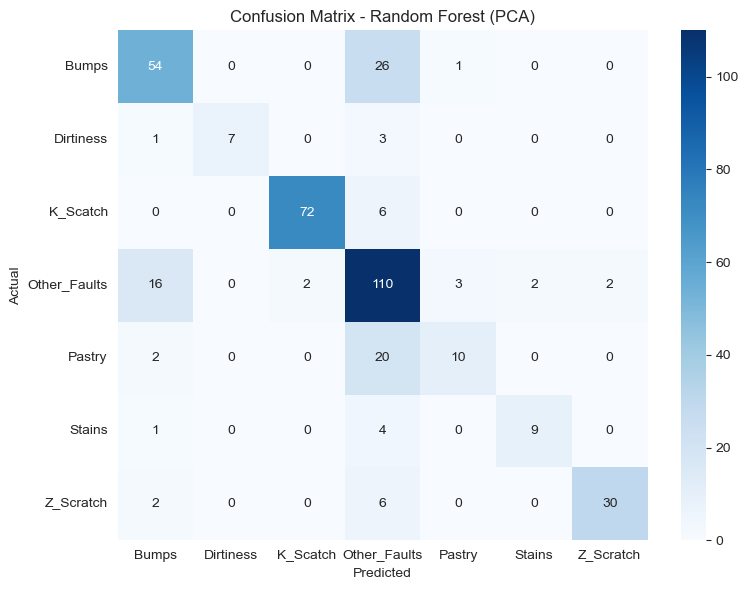

In [56]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test_pca)

acc_rf_pca  = accuracy_score(y_test, y_pred)
prec_rf_pca = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_rf_pca  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_rf_pca   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy :", acc_rf_pca)
print("Precision:", prec_rf_pca)
print("Recall   :", rec_rf_pca)
print("F1-score :", f1_rf_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_rf.classes_,
    yticklabels=best_rf.classes_
)
plt.title("Confusion Matrix - Random Forest (PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

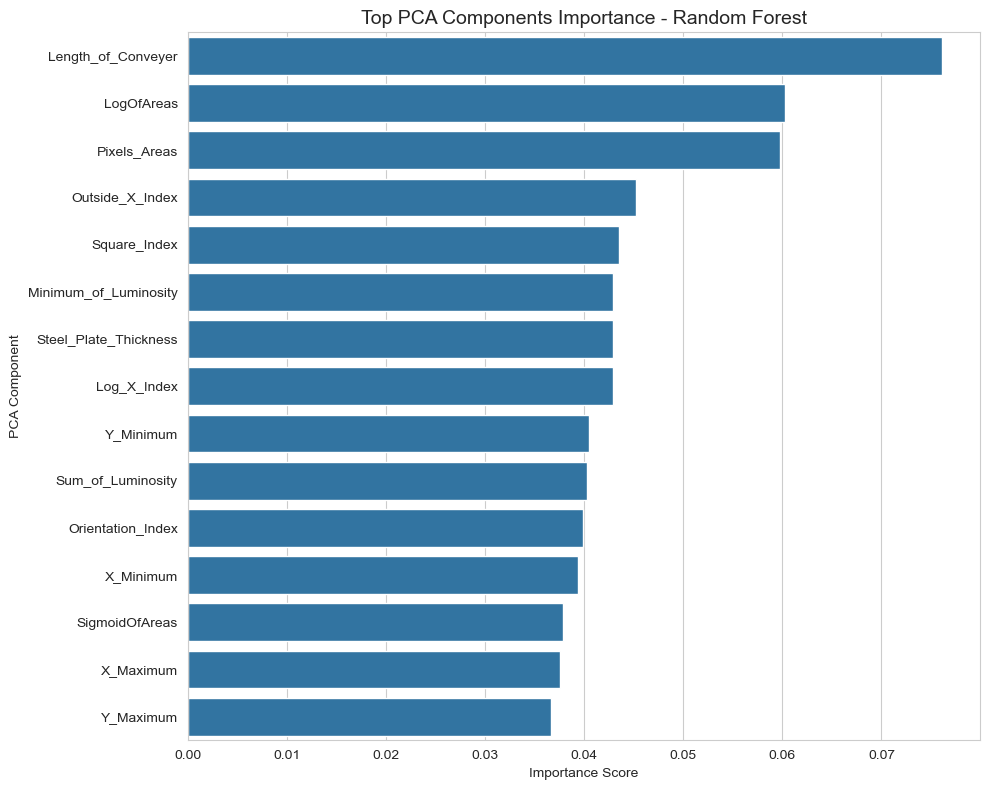

In [57]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top PCA Components Importance - Random Forest", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("PCA Component")
plt.tight_layout()
plt.show()


### **Naive Bayes**

In [58]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Định nghĩa không gian tham số cho GaussianNB
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 3. Khởi tạo mô hình
nb_model = GaussianNB()

# 4. Cấu hình GridSearchCV với cv=skf
grid_search_nb = GridSearchCV(
    estimator=nb_model, 
    param_grid=param_grid_nb, 
    cv=skf,             # Sử dụng StratifiedKFold ở đây
    verbose=1, 
    scoring='accuracy',
    n_jobs=-1           # Sử dụng toàn bộ nhân CPU để chạy nhanh hơn
)

# 5. Huấn luyện
grid_search_nb.fit(X_train_pca, y_train)
best_nb_model = grid_search_nb.best_estimator_
# 6. Kết quả tối ưu
print(f"Tham số tốt nhất: {grid_search_nb.best_params_}")
print(f"Độ chính xác tốt nhất (CV): {grid_search_nb.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Tham số tốt nhất: {'var_smoothing': 0.0015199110829529332}
Độ chính xác tốt nhất (CV): 0.6952



Naive Bayes Performance (PCA):
Accuracy : 0.6838046272493573
Precision: 0.6932917358672265
Recall   : 0.6838046272493573
F1-score : 0.6862062835750601

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.57      0.65      0.61        81
   Dirtiness       1.00      0.64      0.78        11
    K_Scatch       0.89      0.86      0.88        78
Other_Faults       0.61      0.63      0.62       135
      Pastry       0.54      0.47      0.50        32
      Stains       0.83      0.71      0.77        14
   Z_Scratch       0.83      0.76      0.79        38

    accuracy                           0.68       389
   macro avg       0.75      0.68      0.71       389
weighted avg       0.69      0.68      0.69       389



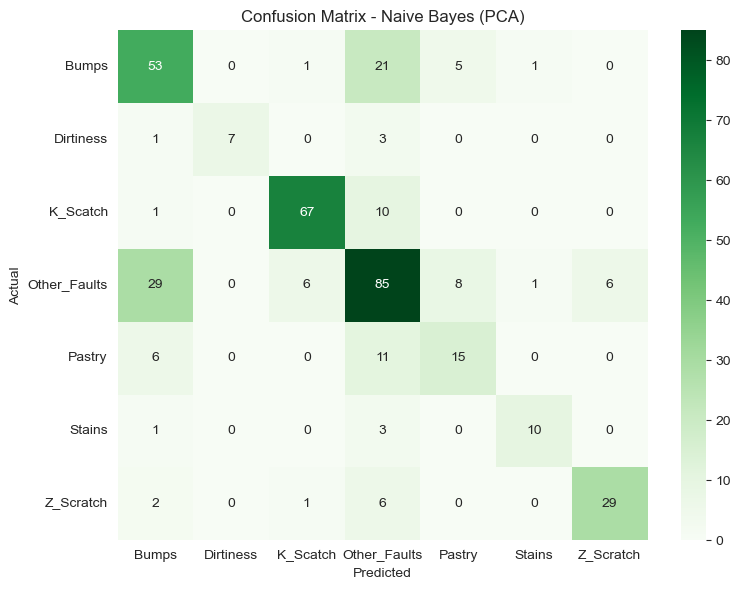

In [59]:
y_pred = best_nb_model.predict(X_test_pca)
acc_nb_pca  = accuracy_score(y_test, y_pred)
prec_nb_pca = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_nb_pca  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_nb_pca   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\nNaive Bayes Performance (PCA):")
print("Accuracy :", acc_nb_pca)
print("Precision:", prec_nb_pca)
print("Recall   :", rec_nb_pca)
print("F1-score :", f1_nb_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Confusion Matrix - Naive Bayes (PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


### **SVM**

In [60]:
# 1. Khởi tạo StratifiedKFold (giữ nguyên random_state=42 như trước)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Định nghĩa không gian tham số
# Thường dùng thang log để bao phủ dải rộng các giá trị
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# 3. Khởi tạo mô hình SVC
# Giữ các setting quan trọng của bạn: probability=True, class_weight='balanced'
svm_base = SVC(
    probability=True, 
    class_weight='balanced', 
    random_state=42
)

# 4. Cấu hình GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=skf,
    scoring='f1_weighted', # Dùng f1_weighted sẽ tốt hơn nếu data bị lệch class
    verbose=1,
    n_jobs=-1
)

# 5. Huấn luyện
grid_search_svm.fit(X_train_pca, y_train)

# 6. Lấy mô hình tốt nhất
best_svm_model = grid_search_svm.best_estimator_

print(f"Tham số tốt nhất: {grid_search_svm.best_params_}")
print(f"F1-score tốt nhất (CV): {grid_search_svm.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Tham số tốt nhất: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
F1-score tốt nhất (CV): 0.7484


Accuracy : 0.7377892030848329
Precision: 0.7512149204692511
Recall   : 0.7377892030848329
F1-score : 0.7406000560202538

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.64      0.65      0.65        81
   Dirtiness       0.83      0.91      0.87        11
    K_Scatch       0.97      0.92      0.95        78
Other_Faults       0.72      0.61      0.66       135
      Pastry       0.45      0.69      0.54        32
      Stains       0.80      0.86      0.83        14
   Z_Scratch       0.85      0.92      0.89        38

    accuracy                           0.74       389
   macro avg       0.75      0.80      0.77       389
weighted avg       0.75      0.74      0.74       389



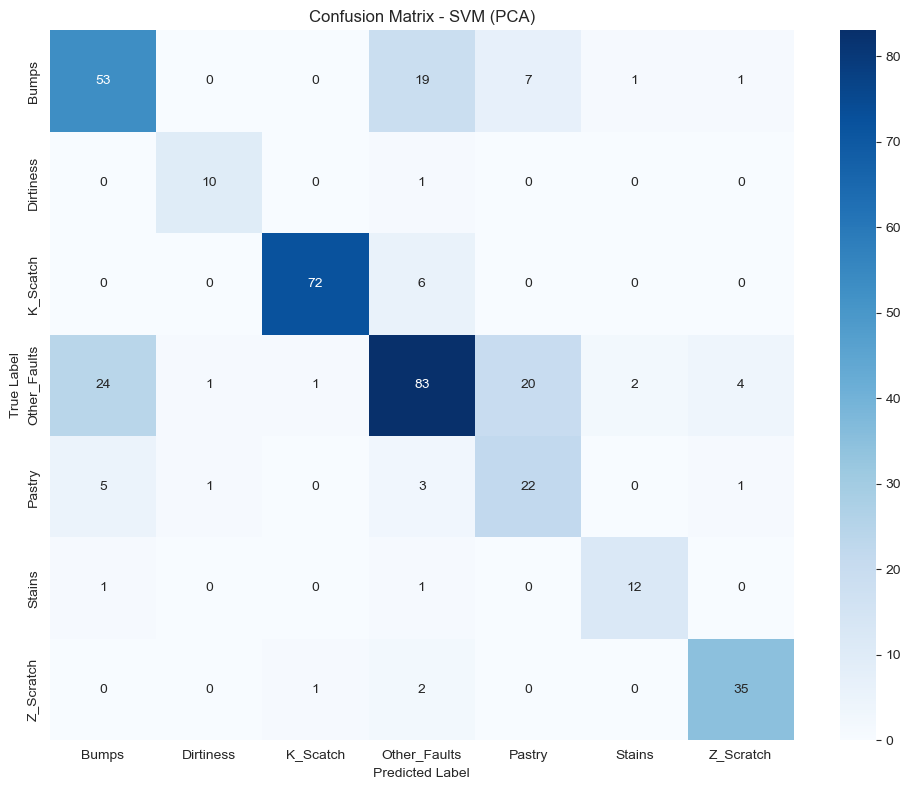

In [61]:
y_pred = best_svm_model.predict(X_test_pca)

acc_svm_pca  = accuracy_score(y_test, y_pred)
prec_svm_pca = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_svm_pca  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_svm_pca   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy :", acc_svm_pca)
print("Precision:", prec_svm_pca)
print("Recall   :", rec_svm_pca)
print("F1-score :", f1_svm_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix - SVM (PCA)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### **ANN(MLP)**

In [62]:
# Encode multiclass labels
le = LabelEncoder()
y_train_ann = le.fit_transform(y_train)
y_test_ann  = le.transform(y_test)

# Convert type
X_train_ann = X_train_pca.astype(np.float32)
X_test_ann  = X_test_pca.astype(np.float32)
y_train_ann = y_train_ann.astype(np.int32)
y_test_ann  = y_test_ann.astype(np.int32)

num_classes = len(np.unique(y_train_ann))
input_dim = X_train_ann.shape[1]

print("Số lớp:", num_classes)
print("Số features:", input_dim)

Số lớp: 7
Số features: 12


In [63]:


# 1. Xây dựng mô hình ANN với tham số mới
ann_model = Sequential()
ann_model.add(Input(shape=(input_dim,)))

# Layer 1: 64 neurons, Dropout 0.1
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dropout(0.1)) # Cập nhật từ 0.2 -> 0.1

# Layer 2: 32 neurons, Dropout 0.1
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.1)) # Cập nhật từ 0.2 -> 0.1

# Output Layer cho nhiều lớp
ann_model.add(Dense(num_classes, activation='softmax'))

# 2. Compile model
# Sử dụng optimizer 'adam' như yêu cầu
ann_model.compile(
    optimizer=Adam(), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# 3. Huấn luyện với epochs và batch_size mới
history = ann_model.fit(
    X_train_ann, y_train_ann,
    validation_split=0.2,
    epochs=100,      # Cập nhật từ 60 -> 100
    batch_size=64,   # Cập nhật từ 32 -> 64
    verbose=1
)

# 4. Dự đoán
y_pred_prob = ann_model.predict(X_test_ann)
y_pred = np.argmax(y_pred_prob, axis=1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,143 (12.28 KB)

 Trainable params: 3,143 (12.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.1180 - loss: 2.0577 - val_accuracy: 0.3215 - val_loss: 1.6594
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3841 - loss: 1.5831 - val_accuracy: 0.5209 - val_loss: 1.3969
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5335 - loss: 1.3078 - val_accuracy: 0.5691 - val_loss: 1.2426
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5877 - loss: 1.1781 - val_accuracy: 0.6238 - val_loss: 1.1249
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6152 - loss: 1.0702 - val_accuracy: 0.6431 - val_loss: 1.0308
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6322 - loss: 1.0052 - val_accuracy: 0.6688 - val_loss: 0.9587
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6507 - loss: 0.9663 - val_accuracy: 0.6881 - val_loss: 0.9055
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6703 - loss: 0.9003 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ANN (PCA)
Accuracy : 0.7557840616966581
Precision: 0.759794935949677
Recall   : 0.7557840616966581
F1 Score : 0.7538050625655396

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.70      0.60      0.65        81
   Dirtiness       1.00      0.55      0.71        11
    K_Scatch       0.90      0.96      0.93        78
Other_Faults       0.68      0.76      0.72       135
      Pastry       0.57      0.53      0.55        32
      Stains       0.86      0.86      0.86        14
   Z_Scratch       0.94      0.84      0.89        38

    accuracy                           0.76       389
   macro avg       0.81      0.73      0.76       389
weighted avg       0.76      0.76      0.75       389



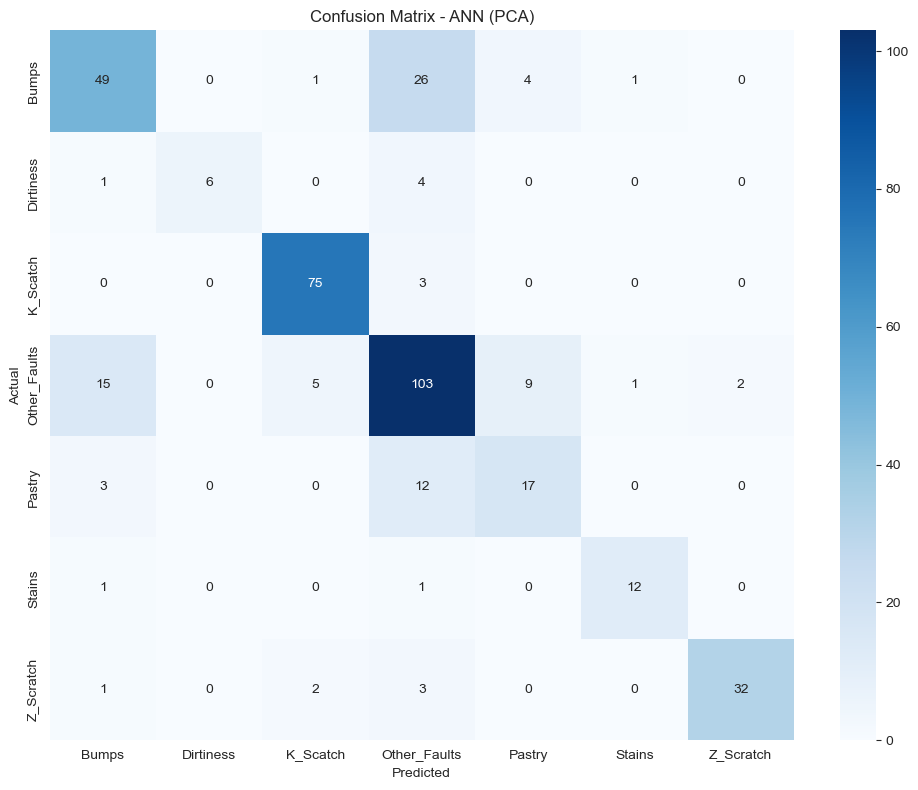

In [64]:
y_pred_prob = ann_model.predict(X_test_ann)
y_pred = np.argmax(y_pred_prob, axis=1)

acc_ann_pca  = accuracy_score(y_test_ann, y_pred)
prec_ann_pca = precision_score(y_test_ann, y_pred, average="weighted", zero_division=0)
rec_ann_pca  = recall_score(y_test_ann, y_pred, average="weighted", zero_division=0)
f1_ann_pca   = f1_score(y_test_ann, y_pred, average="weighted", zero_division=0)

print("ANN (PCA)")
print("Accuracy :", acc_ann_pca)
print("Precision:", prec_ann_pca)
print("Recall   :", rec_ann_pca)
print("F1 Score :", f1_ann_pca)

print("\nClassification Report:")
print(classification_report(
    y_test_ann, y_pred,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test_ann, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - ANN (PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


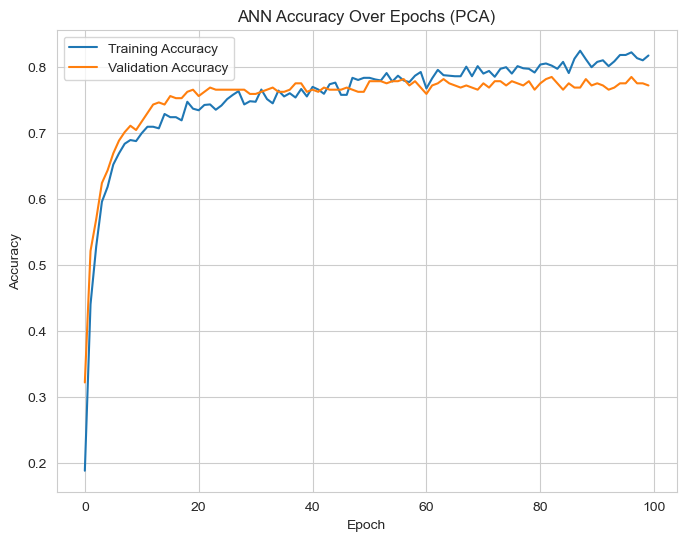

In [65]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("ANN Accuracy Over Epochs (PCA)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### **LSTM**

In [66]:
le = LabelEncoder()

y_train_lstm = le.fit_transform(y_train)
y_test_lstm  = le.transform(y_test)

y_train_lstm = y_train_lstm.astype(np.int32)
y_test_lstm  = y_test_lstm.astype(np.int32)

X_train_lstm = X_train_pca.astype(np.float32)
X_test_lstm  = X_test_pca.astype(np.float32)

In [67]:
# (samples, timesteps=1, features=PCA_dim)
X_train_lstm = X_train_lstm.reshape(
    (X_train_lstm.shape[0], 1, X_train_lstm.shape[1])
)
X_test_lstm = X_test_lstm.reshape(
    (X_test_lstm.shape[0], 1, X_test_lstm.shape[1])
)

num_classes = len(np.unique(y_train_lstm))
input_dim = X_train_lstm.shape[2]

print("Số lớp:", num_classes)
print("Số features (PCA):", input_dim)


Số lớp: 7
Số features (PCA): 12


In [68]:
model = Sequential([
    Input(shape=(1, input_dim)),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 128)         │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,215 (493.03 KB)

 Trainable params: 126,215 (493.03 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.3040 - loss: 1.9237 - val_accuracy: 0.5145 - val_loss: 1.8319
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5132 - loss: 1.7620 - val_accuracy: 0.4566 - val_loss: 1.5469
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5083 - loss: 1.4523 - val_accuracy: 0.4791 - val_loss: 1.3532
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5415 - loss: 1.2427 - val_accuracy: 0.5370 - val_loss: 1.2128
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5373 - loss: 1.1311 - val_accuracy: 0.5627 - val_loss: 1.1111
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6022 - loss: 1.0036 - val_accuracy: 0.6174 - val_loss: 1.0332
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6312 - loss: 0.9641 - val_accuracy: 0.6495 - val_loss: 0.9458
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6833 - loss: 0.8480 - val_accuracy: 0.6817 - 

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step

LSTM Performance (PCA):
Accuracy : 0.7634961439588689
Precision: 0.764629421288431
Recall   : 0.7634961439588689
F1-score : 0.7615962008161213

Classification Report:
              precision    recall  f1-score   support

       Bumps       0.69      0.67      0.68        81
   Dirtiness       1.00      0.55      0.71        11
    K_Scatch       0.90      0.96      0.93        78
Other_Faults       0.70      0.72      0.71       135
      Pastry       0.65      0.62      0.63        32
      Stains       0.92      0.79      0.85        14
   Z_Scratch       0.83      0.89      0.86        38

    accuracy                           0.76       389
   macro avg       0.81      0.74      0.77       389
weighted avg       0.76      0.76      0.76       389



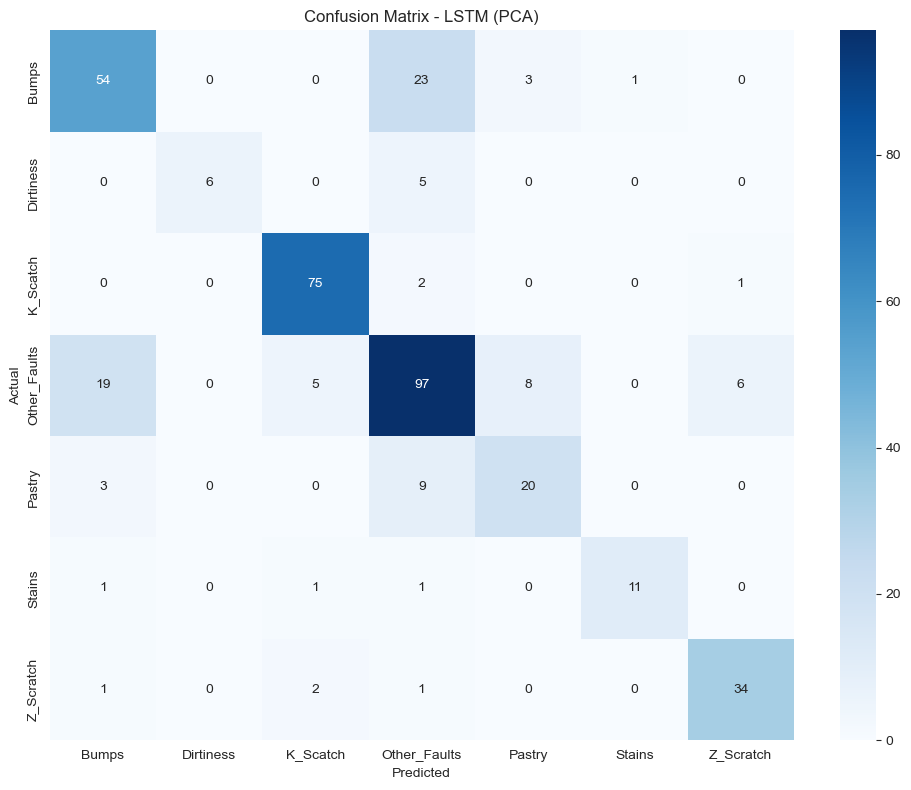

In [70]:
y_pred_prob = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)

acc_lstm_pca  = accuracy_score(y_test_lstm, y_pred)
prec_lstm_pca = precision_score(y_test_lstm, y_pred, average="weighted", zero_division=0)
rec_lstm_pca  = recall_score(y_test_lstm, y_pred, average="weighted", zero_division=0)
f1_lstm_pca   = f1_score(y_test_lstm, y_pred, average="weighted", zero_division=0)

print("\nLSTM Performance (PCA):")
print("Accuracy :", acc_lstm_pca)
print("Precision:", prec_lstm_pca)
print("Recall   :", rec_lstm_pca)
print("F1-score :", f1_lstm_pca)

print("\nClassification Report:")
print(classification_report(
    y_test_lstm,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test_lstm, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix - LSTM (PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [71]:
# Vẽ biểu đồ accuracy
fig10 = go.Figure()

fig10.add_trace(go.Scatter(
    y=history.history['accuracy'],
    mode='lines',
    name='Training Accuracy'
))

fig10.add_trace(go.Scatter(
    y=history.history['val_accuracy'],
    mode='lines',
    name='Validation Accuracy'
))

fig10.update_layout(
    title="LSTM Accuracy Over Epochs (PCA)",
    xaxis_title="Epoch",
    yaxis_title="Accuracy"
)

fig10.show()

### **So sánh kết quả các mô hình**

So sánh kết quả các mô hình (PCA)
           Model  Accuracy  Precision  Recall  F1-Score
0  Random Forest    0.7506     0.7693  0.7506    0.7469
1    Naive Bayes    0.6838     0.6933  0.6838    0.6862
2            SVM    0.7378     0.7512  0.7378    0.7406
3            ANN    0.7558     0.7598  0.7558    0.7538
4           LSTM    0.7635     0.7646  0.7635    0.7616


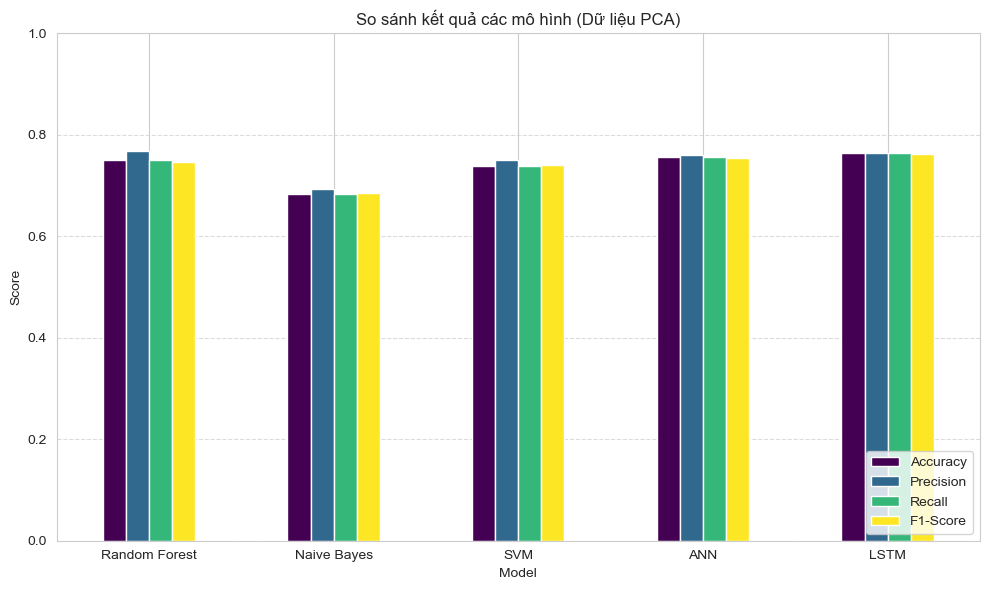

In [72]:
# Gom kết quả PCA
results_pca = pd.DataFrame({
    "Model": ["Random Forest", "Naive Bayes", "SVM", "ANN", "LSTM"],
    "Accuracy":  [acc_rf_pca, acc_nb_pca, acc_svm_pca, acc_ann_pca, acc_lstm_pca],
    "Precision": [prec_rf_pca, prec_nb_pca, prec_svm_pca, prec_ann_pca, prec_lstm_pca],
    "Recall":    [rec_rf_pca, rec_nb_pca, rec_svm_pca, rec_ann_pca, rec_lstm_pca],
    "F1-Score":  [f1_rf_pca,  f1_nb_pca,  f1_svm_pca,  f1_ann_pca,  f1_lstm_pca]
})

# Làm tròn số liệu
results_pca[["Accuracy","Precision","Recall","F1-Score"]] = \
    results_pca[["Accuracy","Precision","Recall","F1-Score"]].round(4)

print("So sánh kết quả các mô hình (PCA)")
print(results_pca)

# Vẽ biểu đồ 
results_pca.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10,6),
    colormap="viridis",
    rot=0
)

plt.title("So sánh kết quả các mô hình (Dữ liệu PCA)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()